In [1]:
import os
import polars as pl
import pandas as pd
import pyranges as pr
from tqdm import tqdm
import matplotlib.pyplot as plt
from plotnine import *

/opt/modules/i12g/anaconda/envs/sl-ukg/lib/python3.12/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
LOCAL_DATA_DIR = '/s/project/deeprvat_wgs/input_data/annotations/qced_maf1e-3_loftee_olink_genes_EURunrelated/'
RAP_DATA_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"

# Add UKBBGym annotations

1. MAC and Sample count
2. VEP coding / non-coding
4. Amino acid position
5. Protein domains (MOBI db)

In [3]:
# Download variant metadata file

!dx download {RAP_DATA_DIR}/qced_maf1e-3_loftee_olink_genes_EURunrelated_variant_metadata.parquet -o {LOCAL_DATA_DIR}/

varmeta_df = pl.read_parquet(f'{LOCAL_DATA_DIR}/qced_maf1e-3_loftee_olink_genes_EURunrelated_variant_metadata.parquet')
varmeta_df.head()

Error: path "/s/project/deeprvat_wgs/input_data/annotations/qced_maf1e-3_lofte
e_olink_genes_EURunrelated//qced_maf1e-3_loftee_olink_genes_EURunrelated_varia
nt_metadata.parquet" already exists but -f/--overwrite was not set


id,sc_ukb,ac_ukb,chrom,pos,ref,alt,mac_ukb
str,u64,i64,str,str,str,str,i64
"""chr10:20162746:G:C""",1,1,"""chr10""","""20162746""","""G""","""C""",1
"""chr10:20164255:A:G""",1,1,"""chr10""","""20164255""","""A""","""G""",1
"""chr10:20164674:G:C""",1,1,"""chr10""","""20164674""","""G""","""C""",1
"""chr10:20165243:A:G""",1,1,"""chr10""","""20165243""","""A""","""G""",1
"""chr10:20165245:C:T""",1,1,"""chr10""","""20165245""","""C""","""T""",1


In [4]:
# Download annotations file
!dx download {RAP_DATA_DIR}/annotations.parquet -o {LOCAL_DATA_DIR}/

anno_df = pl.scan_parquet(f'{LOCAL_DATA_DIR}/annotations.parquet')
anno_df.head().collect()

Error: path "/s/project/deeprvat_wgs/input_data/annotations/qced_maf1e-3_lofte
e_olink_genes_EURunrelated//annotations.parquet" already exists but
-f/--overwrite was not set


id,ac_ukb_eur,mac_ukb_eur,chrom,pos,ref,alt,qual,filter,info,location,allele,gene,feature,feature_type,consequence,cdna_position,cds_position,protein_position,amino_acids,codons,existing_variation,impact,distance,strand,flags,biotype,canonical,ensp,sift,polyphen,gnomade_af,gnomade_afr_af,gnomade_amr_af,gnomade_asj_af,gnomade_eas_af,gnomade_fin_af,…,gerprspval,gerps,grantham,remapoverlapcl,remapoverlaptf,roulette-ar,roulette-mr,zoopriphylop,zoorocc,zoouce,zooverphylop,bstatistic,cdnapos,dbscsnv-ada_score,dbscsnv-rf_score,mamphcons,mamphylop,mindisttse,mindisttss,mirsvr-aln,mirsvr-e,mirsvr-score,motifdist,motifecount,motifehipos,motifescorechng,priphcons,priphylop,relcdspos,relprotpos,relcdnapos,toverlapmotifs,targetscan,verphcons,verphylop,domain,ensembleregulatoryfeature
str,u64,u64,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,str
"""chr19:17122403:G:A""",1,1,"""chr19""",17122403,"""G""","""A""",""".""",""".""",""".""","""chr19:17122403""","""A""","""ENSG00000099331""","""ENST00000682292""","""Transcript""","""intron_variant""",null,null,null,null,null,null,"""MODIFIER""",null,"""1""",null,"""protein_coding""","""YES""","""ENSP00000507803""",null,null,null,null,null,null,null,null,…,null,0.262,null,2.0,2.0,null,0.151,0.001,null,null,-0.865,964.0,null,null,null,0.008,0.392,89697,20685,null,null,null,null,null,null,null,0.008,0.395,null,null,null,null,null,0.007,0.379,null,null
"""chr19:19643593:C:A""",1,1,"""chr19""",19643593,"""C""","""A""",""".""",""".""",""".""","""chr19:19643593""","""A""","""ENSG00000105726""","""ENST00000357324""","""Transcript""","""downstream_gene_variant""",null,null,null,null,null,null,"""MODIFIER""",1605,"""-1""",null,"""protein_coding""","""YES""","""ENSP00000349877""",null,null,null,null,null,null,null,null,…,null,0.399,null,233.0,123.0,null,0.083,0.979,null,null,1.508,440.0,null,null,null,0.015,-0.044,3265,6,null,null,null,0.41,null,null,null,0.576,0.418,null,null,null,2.0,null,0.009,-0.03,null,"""Promoter"""
"""chr1:228280185:A:T""",1,1,"""chr1""",228280185,"""A""","""T""",""".""",""".""",""".""","""chr1:228280185""","""T""","""ENSG00000154358""","""ENST00000680850""","""Transcript""","""missense_variant""","""9117/27019""","""8957/26778""","""2986/8925""","""E/V""","""gAg/gTg""",null,"""MODERATE""",null,"""1""",null,"""protein_coding""","""YES""","""ENSP00000505517""",null,0.98,null,null,null,null,null,null,…,0.0,5.06,121.0,8.0,7.0,null,0.03,0.671,null,null,0.844,433.0,9117.0,null,null,1.0,1.823,4011,3007,null,null,null,null,null,null,null,0.218,0.47,0.334,0.335,0.337,null,null,0.974,3.098,"""lcompl""",null
"""chr1:228297766:A:G""",1,1,"""chr1""",228297766,"""A""","""G""",""".""",""".""",""".""","""chr1:228297766""","""G""","""ENSG00000154358""","""ENST00000680850""","""Transcript""","""intron_variant""",null,null,null,null,null,null,"""MODIFIER""",null,"""1""",null,"""protein_coding""","""YES""","""ENSP00000505517""",null,null,null,null,null,null,null,null,…,null,-1.68,null,1.0,1.0,null,0.073,0.0,null,null,-0.519,440.0,null,null,null,0.0,-0.191,1719,2874,null,null,null,null,null,null,null,0.007,0.328,null,null,null,null,null,0.0,-0.071,null,null
"""chr1:228298257:A:ATGTGGGTGTGTG""",1,1,"""chr1""",228298257,"""A""","""ATGTGGGTGTGTG""",""".""",""".""",""".""","""chr1:228298257-228298258""","""TGTGGGTGTGTG""","""ENSG00000154358""","""ENST00000680850""","""Transcript""","""intron_variant""",null,null,null,null,null,null,"""MODIFIER""",null,"""1""",null,"""protein_coding""","""YES""","""ENSP00000505517""",null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [5]:
# Download annotations fill_na file
!dx download {RAP_DATA_DIR}/annotations_fill_na.parquet -o {LOCAL_DATA_DIR}/

anno_fillna_df = pl.scan_parquet(f'{LOCAL_DATA_DIR}/annotations_fill_na.parquet')
anno_fillna_df.head().collect()

Error: path "/s/project/deeprvat_wgs/input_data/annotations/qced_maf1e-3_lofte
e_olink_genes_EURunrelated//annotations_fill_na.parquet" already exists but
-f/--overwrite was not set


id,ac_ukb_eur,mac_ukb_eur,chrom,pos,ref,alt,region,mac_ukb,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_adipose_subcutaneous,abexp_adipose_visceral__omentum,abexp_adrenal_gland,abexp_artery_aorta,…,esmscoreinframe_is_na,esmscoremissense_is_na,gc_is_na,gerpn_is_na,gerps_is_na,grantham_is_na,remapoverlapcl_is_na,remapoverlaptf_is_na,roulette-ar_is_na,roulette-mr_is_na,zoopriphylop_is_na,zoouce_is_na,zooverphylop_is_na,bstatistic_is_na,cdnapos_is_na,dbscsnv-ada_score_is_na,dbscsnv-rf_score_is_na,mamphcons_is_na,mamphylop_is_na,mindisttse_is_na,mindisttss_is_na,mirsvr-aln_is_na,mirsvr-e_is_na,mirsvr-score_is_na,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na
str,u64,u64,str,i64,str,str,str,u64,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8
"""chr18:56603287:T:G""",1,1,"""chr18""",56603287,"""T""","""G""","""ENSG00000091164""",2,1.0,0.0,0.718,-0.102671,0.0,"""TXNL1|0.00|0.00|0.00|0.00|-26|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-2.52,0.0,0.0,-0.006189,-0.006189,-0.006189,-0.006189,…,1,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0
"""chr18:56611517:A:G""",1,1,"""chr18""",56611517,"""A""","""G""","""ENSG00000091164""",1,1.0,0.0,0.967,-0.026532,0.0,"""TXNL1|0.01|0.00|0.00|0.00|-22|…",0,0,0.0,0.0,0.01,0.01,0.01,0.003,0.000423,0,0,0,0,0,1,-2.0,0.0,0.0,-0.006189,-0.006189,-0.006189,-0.006189,…,1,1,0,0,0,1,1,1,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0
"""chr19:34340475:G:A""",1,1,"""chr19""",34340475,"""G""","""A""","""ENSG00000166398""",1,1.0,0.0,6.95,0.652671,0.0,"""0""",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-0.82,0.0,0.0,-0.005749,-0.005749,-0.005749,-0.005749,…,1,1,0,0,0,1,1,1,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0
"""chr19:5256210:T:C""",1,1,"""chr19""",5256210,"""T""","""C""","""ENSG00000105426""",1,1.0,0.0,22.5,3.43399,0.0,"""PTPRS|0.00|0.00|0.00|0.00|7|40…",0,0,0.0,0.0,0.0,0.0,0.0,0.003,0.000308,0,0,0,0,0,1,-6.43,0.0,0.0,-0.07183,-0.070551,-0.07183,-0.07183,…,1,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0
"""chr19:5257316:G:C""",1,1,"""chr19""",5257316,"""G""","""C""","""ENSG00000105426""",3,1.0,0.0,5.198,0.474529,0.0,"""PTPRS|0.00|0.00|0.00|0.00|1|-5…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-1.51,0.0,0.0,-0.005501,-0.005501,-0.005501,-0.005501,…,1,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,0,1,1,1,0,0,1,1,1,0,1,0,0


---
# Get AbExp min, and max; drop the individuals abexp tissue columns

In [6]:
ab_exp_tissue_cols = [c for c in anno_fillna_df.columns if (c.startswith('abexp_') and not c.endswith('_is_na'))]
ab_exp_tissue_cols = list(set(ab_exp_tissue_cols) - {'abexp_abs_max'})
ab_exp_tissue_cols

/scratch/tmp/lond/ipykernel_1589881/985620641.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.


['abexp_stomach',
 'abexp_adipose_subcutaneous',
 'abexp_brain_substantia_nigra',
 'abexp_esophagus_gastroesophageal_junction',
 'abexp_thyroid',
 'abexp_adrenal_gland',
 'abexp_uterus',
 'abexp_minor_salivary_gland',
 'abexp_cells_cultured_fibroblasts',
 'abexp_heart_atrial_appendage',
 'abexp_brain_amygdala',
 'abexp_whole_blood',
 'abexp_vagina',
 'abexp_brain_hypothalamus',
 'abexp_heart_left_ventricle',
 'abexp_colon_sigmoid',
 'abexp_skin_not_sun_exposed__suprapubic',
 'abexp_skin_sun_exposed__lower_leg',
 'abexp_brain_frontal_cortex__ba9',
 'abexp_small_intestine_terminal_ileum',
 'abexp_cells_ebv-transformed_lymphocytes',
 'abexp_artery_tibial',
 'abexp_prostate',
 'abexp_esophagus_muscularis',
 'abexp_lung',
 'abexp_artery_coronary',
 'abexp_spleen',
 'abexp_kidney_cortex',
 'abexp_artery_aorta',
 'abexp_pancreas',
 'abexp_colon_transverse',
 'abexp_ovary',
 'abexp_esophagus_mucosa',
 'abexp_brain_hippocampus',
 'abexp_muscle_skeletal',
 'abexp_brain_cortex',
 'abexp_breast_ma

In [7]:
abexp_df = (
    anno_fillna_df
    .with_columns(
        abexp_min = pl.min_horizontal([pl.col(c) for c in ab_exp_tissue_cols]),
        abexp_max = pl.max_horizontal([pl.col(c) for c in ab_exp_tissue_cols]),
        abexp_mean = pl.mean_horizontal([pl.col(c) for c in ab_exp_tissue_cols]),
    )
    .select(['id', 'region', 'abexp_abs_max', 'abexp_min', 'abexp_max', 'abexp_mean'])
    .collect()
)

abexp_df

id,region,abexp_abs_max,abexp_min,abexp_max,abexp_mean
str,str,f32,f32,f32,f32
"""chr18:56603287:T:G""","""ENSG00000091164""",0.006189,-0.006189,-0.00487,-0.006066
"""chr18:56611517:A:G""","""ENSG00000091164""",0.006189,-0.006189,0.000962,-0.00592
"""chr19:34340475:G:A""","""ENSG00000166398""",0.006438,-0.006438,-0.005119,-0.005691
"""chr19:5256210:T:C""","""ENSG00000105426""",1.334633,-1.334633,0.012832,-0.196859
"""chr19:5257316:G:C""","""ENSG00000105426""",0.006871,-0.005501,0.006871,-0.005067
…,…,…,…,…,…
"""chr16:179290:T:A""","""ENSG00000086506""",0.0,0.0,0.0,0.0
"""chr7:148348869:A:G""","""ENSG00000174469""",0.006358,-0.006358,0.0,-0.001784
"""chr5:138680487:A:G""","""ENSG00000044115""",0.003182,0.002221,0.003182,0.00301


In [ ]:
ab_exp_cols = [c for c in anno_fillna_df.columns if c.startswith('abexp_')]

drop_abexp_cols = list(set(ab_exp_cols) - {'abexp_abs_max', 'abexp_abs_max_is_na'})
drop_abexp_cols += ['ac_ukb_eur', 'mac_ukb_eur', 'mac_ukb']

anno_fillna_df = (
    anno_fillna_df
    .drop(drop_abexp_cols + ['spliceai_pred'])
    .join(abexp_df.lazy(), on=['id', 'region'], how='left')
)

anno_fillna_df.columns

/scratch/tmp/lond/ipykernel_1589881/1642612027.py:1: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
/scratch/tmp/lond/ipykernel_1589881/1642612027.py:12: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.


['id',
 'chrom',
 'pos',
 'ref',
 'alt',
 'region',
 'sift',
 'polyphen',
 'cadd_phred',
 'cadd_raw',
 'am_pathogenicity',
 'spliceai_pred',
 'loftee_hc',
 'loftee_lc',
 'relative_cds_position',
 'next_in_frame_relative',
 'spliceai_delta_score',
 'pangolin_score',
 'delta_score',
 'absplice_dna_max',
 'absplice2_max',
 'five_prime_utr_variant_consequence_uaug_gained',
 'five_prime_utr_variant_consequence_uaug_lost',
 'five_prime_utr_variant_consequence_uframeshift',
 'five_prime_utr_variant_consequence_ustop_gained',
 'five_prime_utr_variant_consequence_ustop_lost',
 'variant_length',
 'gpn_score',
 'promoterai',
 'score_pai3d',
 'abexp_abs_max',
 'gene_length',
 'dist_to_tss',
 'aparent2',
 'cdspos',
 'cpg',
 'dst2splice',
 'esmscoreframeshift',
 'esmscoreinframe',
 'esmscoremissense',
 'gc',
 'gerpn',
 'gerps',
 'grantham',
 'remapoverlapcl',
 'remapoverlaptf',
 'roulette-ar',
 'roulette-mr',
 'zoopriphylop',
 'zoouce',
 'zooverphylop',
 'bstatistic',
 'cdnapos',
 'dbscsnv-ada_score

---
# Annotate UKB MAC and sample counts

In [9]:
anno_fillna_df = (
    anno_fillna_df

    .join(
        varmeta_df.select(['id', 'sc_ukb', 'ac_ukb', 'mac_ukb']).lazy(), 
        on='id', 
        how='inner'
    )
)

---
# Annotate VEP coding regions

In [10]:
vep_cds_relaxed = [
    # LoF variants
    'consequence_stop_gained',
    'consequence_frameshift_variant',

    # Missense and synonymous variants
    'consequence_synonymous_variant',
    'consequence_protein_altering_variant',
    'consequence_missense_variant',

    # Splicing variants
    'consequence_splice_region_variant',
    'consequence_splice_acceptor_variant',
    'consequence_splice_donor_variant',
    'consequence_splice_donor_region_variant',
    'consequence_splice_donor_5th_base_variant',
    'consequence_splice_polypyrimidine_tract_variant',

    # Other coding sequence variants
    'consequence_start_lost',
    'consequence_stop_lost',
    'consequence_start_retained_variant',
    'consequence_stop_retained_variant',
    'consequence_inframe_deletion',
    'consequence_inframe_insertion',
    'consequence_coding_sequence_variant',
]

anno_fillna_df = (
    anno_fillna_df
    .with_columns(
        vep_cds_relaxed = pl.sum_horizontal(vep_cds_relaxed) > 0,
    )
)

---
# MANE CDS & non-MANE CDS only

## 1. Parse GTF & extract MANE / non-MANE CDS regions

In [11]:
gtf_path = "/s/genomes/Gencode/Gencode_human/release_40/gencode.v40.annotation.gtf.gz"

gtf_pl = pl.read_csv(
    gtf_path,
    separator="\t",
    comment_prefix="#",
    has_header=False,
    new_columns=["Chromosome", "source", "Feature", "Start", "End", "score", "Strand", "frame", "attributes"]
).with_row_index("row_nr")

# Parse attributes into columns
atts = (
    gtf_pl.select("row_nr", "attributes")
    .with_columns(attrs_list=pl.col("attributes").str.split("; "))
    .explode("attrs_list")
    .with_columns(
        pl.col("attrs_list").str.split_exact(" ", 1)
        .struct.rename_fields(["attribute", "value"]).alias("fields")
    ).unnest("fields")
    .with_columns(pl.col("value").str.strip_chars('"'))
    .pivot(index="row_nr", on="attribute", values="value", aggregate_function=pl.element().implode())
    .with_columns(pl.col(pl.List).list.join(", ").str.strip_chars(";").replace("", None))
    .with_columns(level=pl.col('level').cast(pl.Int32))
)

gtf = gtf_pl.join(atts, on='row_nr')
gtf

row_nr,Chromosome,source,Feature,Start,End,score,Strand,frame,attributes,gene_id,transcript_id,gene_type,gene_name,transcript_type,transcript_name,exon_number,exon_id,level,transcript_support_level,hgnc_id,tag,havana_gene,havana_transcript,ont,protein_id,ccdsid
u64,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i32,str,str,str,str,str,str,str,str
0,"""chr1""","""HAVANA""","""exon""",11869,12227,""".""","""+""",""".""","""gene_id ""ENSG00000223972.5""; t…","""ENSG00000223972.5""","""ENST00000456328.2""","""transcribed_unprocessed_pseudo…","""DDX11L1""","""processed_transcript""","""DDX11L1-202""","""1""","""ENSE00002234944.1""",2,"""1""","""HGNC:37102""","""basic""","""OTTHUMG00000000961.2""","""OTTHUMT00000362751.1""""",null,null,null
1,"""chr1""","""HAVANA""","""gene""",11869,14409,""".""","""+""",""".""","""gene_id ""ENSG00000223972.5""; g…","""ENSG00000223972.5""",null,"""transcribed_unprocessed_pseudo…","""DDX11L1""",null,null,null,null,2,null,"""HGNC:37102""",null,"""OTTHUMG00000000961.2""""",null,null,null,null
2,"""chr1""","""HAVANA""","""transcript""",11869,14409,""".""","""+""",""".""","""gene_id ""ENSG00000223972.5""; t…","""ENSG00000223972.5""","""ENST00000456328.2""","""transcribed_unprocessed_pseudo…","""DDX11L1""","""processed_transcript""","""DDX11L1-202""",null,null,2,"""1""","""HGNC:37102""","""basic""","""OTTHUMG00000000961.2""","""OTTHUMT00000362751.1""""",null,null,null
3,"""chr1""","""HAVANA""","""exon""",12010,12057,""".""","""+""",""".""","""gene_id ""ENSG00000223972.5""; t…","""ENSG00000223972.5""","""ENST00000450305.2""","""transcribed_unprocessed_pseudo…","""DDX11L1""","""transcribed_unprocessed_pseudo…","""DDX11L1-201""","""1""","""ENSE00001948541.1""",2,"""NA""","""HGNC:37102""","""basic, Ensembl_canonical""","""OTTHUMG00000000961.2""","""OTTHUMT00000002844.2""""","""PGO:0000005, PGO:0000019""",null,null
4,"""chr1""","""HAVANA""","""transcript""",12010,13670,""".""","""+""",""".""","""gene_id ""ENSG00000223972.5""; t…","""ENSG00000223972.5""","""ENST00000450305.2""","""transcribed_unprocessed_pseudo…","""DDX11L1""","""transcribed_unprocessed_pseudo…","""DDX11L1-201""",null,null,2,"""NA""","""HGNC:37102""","""basic, Ensembl_canonical""","""OTTHUMG00000000961.2""","""OTTHUMT00000002844.2""""","""PGO:0000005, PGO:0000019""",null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3283857,"""chrY""","""HAVANA""","""transcript""",57212184,57214397,""".""","""-""",""".""","""gene_id ""ENSG00000227159.8_PAR…","""ENSG00000227159.8_PAR_Y""","""ENST00000507418.6_PAR_Y""","""unprocessed_pseudogene""","""DDX11L16""","""unprocessed_pseudogene""","""DDX11L16-201""",null,null,2,"""NA""","""HGNC:37115""","""basic, Ensembl_canonical, PAR""","""OTTHUMG00000022678.1""","""OTTHUMT00000058841.1""""","""PGO:0000005""",null,null
3283858,"""chrY""","""HAVANA""","""exon""",57213204,57213357,""".""","""-""",""".""","""gene_id ""ENSG00000227159.8_PAR…","""ENSG00000227159.8_PAR_Y""","""ENST00000507418.6_PAR_Y""","""unprocessed_pseudogene""","""DDX11L16""","""unprocessed_pseudogene""","""DDX11L16-201""","""4""","""ENSE00002036959.1""",2,"""NA""","""HGNC:37115""","""basic, Ensembl_canonical, PAR""","""OTTHUMG00000022678.1""","""OTTHUMT00000058841.1""""","""PGO:0000005""",null,null
3283859,"""chrY""","""HAVANA""","""exon""",57213526,57213602,""".""","""-""",""".""","""gene_id ""ENSG00000227159.8_PAR…","""ENSG00000227159.8_PAR_Y""","""ENST00000507418.6_PAR_Y""","""unprocessed_pseudogene""","""DDX11L16""","""unprocessed_pseudogene""","""DDX11L16-201""","""3""","""ENSE00002021169.1""",2,"""NA""","""HGNC:37115""","""basic, Ensembl_canonical, PAR""","""OTTHUMG00000022678.1""","""OTTHUMT00000058841.1""""","""PGO:0000005""",null,null


In [12]:
# Filter to protein-coding CDS features only
cds = gtf.filter(
    (pl.col('gene_type') == 'protein_coding') & (pl.col('Feature') == 'CDS')
)

# MANE CDS: merged regions from MANE_Select transcripts
mane_cds_pr = pr.PyRanges(
    cds.filter(pl.col('tag').str.contains('MANE_Select')).to_pandas()
).merge()

# Non-MANE CDS: merged regions from non-MANE transcripts, subtracting MANE CDS
non_mane_cds_pr = pr.PyRanges(
    cds.filter(~pl.col('tag').str.contains('MANE_Select')).to_pandas()
).merge().subtract(mane_cds_pr)

print(f"MANE CDS regions: {len(mane_cds_pr)}")
print(f"Non-MANE CDS regions: {len(non_mane_cds_pr)}")

MANE CDS regions: 186596
Non-MANE CDS regions: 32619


## 2. Load annotations & overlap with CDS regions

In [13]:
# anno_df = pl.scan_parquet(f'{LOCAL_DATA_DIR}/annotations_fillna_ukbgym.parquet')
anno_fillna_df.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,roulette-ar_is_na,roulette-mr_is_na,zoopriphylop_is_na,zoouce_is_na,zooverphylop_is_na,bstatistic_is_na,cdnapos_is_na,dbscsnv-ada_score_is_na,dbscsnv-rf_score_is_na,mamphcons_is_na,mamphylop_is_na,mindisttse_is_na,mindisttss_is_na,mirsvr-aln_is_na,mirsvr-e_is_na,mirsvr-score_is_na,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool
"""chr10:20162746:G:C""","""chr10""",20162746,"""G""","""C""","""ENSG00000120594""",1.0,0.0,3.388,0.310595,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|8|4…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.62,0.0,0.0,0.006063,473619,346508,0.0,0.0,0.027,0.0,…,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006063,-0.006063,0.0,-0.005258,1,1,1,false
"""chr10:20164255:A:G""","""chr10""",20164255,"""A""","""G""","""ENSG00000120594""",1.0,0.0,5.802,0.533322,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|33|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-3.14,0.0,0.0,0.012088,473619,348017,0.0,0.0,0.013,0.0,…,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,0,1,1,1,0,0,1,1,1,0,1,0,0,0.012088,-0.012088,0.0,-0.010914,1,1,1,false
"""chr10:20164674:G:C""","""chr10""",20164674,"""G""","""C""","""ENSG00000120594""",1.0,0.0,0.168,-0.47335,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|6|4…",0,0,0.0,0.0,0.0,0.0,0.0,0.003,0.000341,0,0,0,0,0,1,-0.49,0.0,0.0,0.03541,473619,348436,0.04473,0.0,0.027,0.0,…,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.03541,-0.03541,0.0,-0.012549,1,1,1,false
"""chr10:20165243:A:G""","""chr10""",20165243,"""A""","""G""","""ENSG00000120594""",1.0,0.0,11.04,1.064876,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|-6|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.43,0.0,0.0,0.006063,473619,349005,0.0,0.0,0.013,0.0,…,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006063,-0.006063,0.0,-0.005258,1,1,1,false
"""chr10:20165245:C:T""","""chr10""",20165245,"""C""","""T""","""ENSG00000120594""",1.0,0.0,0.567,-0.161835,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|11|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-0.92,0.0,0.0,0.006261,473619,349007,0.0,0.0,0.013,0.0,…,1,0,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006261,-0.006261,0.0,-0.005179,1,1,1,false


In [14]:
# Convert annotations to PyRanges for overlap
anno = (
    anno_fillna_df
    .with_columns(
        Chromosome=pl.col('chrom'),
        Start=pl.col('pos') - 1,
        End=pl.col('pos') - 1 + pl.col('ref').str.len_chars(),
        gene=pl.col('region'),
    )
    .select(['id', 'Chromosome', 'Start', 'End', 'ref', 'alt', 'gene'])
    .collect(engine='streaming')
)
anno_pr = pr.PyRanges(anno.to_pandas())

# Overlap with MANE and non-MANE CDS regions
mane_cds_vars = pl.from_pandas(anno_pr.overlap(mane_cds_pr).df).with_columns(mane_cds=pl.lit(True)).select(['id', 'gene', 'mane_cds'])
non_mane_cds_vars = pl.from_pandas(anno_pr.overlap(non_mane_cds_pr).df).with_columns(non_mane_cds=pl.lit(True)).select(['id', 'gene', 'non_mane_cds'])

mane_cds_vars

id,gene,mane_cds
str,str,bool
"""chr1:21834883:C:G""","""ENSG00000142798""",true
"""chr1:229558380:C:G""","""ENSG00000135776""",true
"""chr1:207322416:C:T""","""ENSG00000196352""",true
"""chr1:225939534:C:T""","""ENSG00000143768""",true
"""chr1:228372337:G:A""","""ENSG00000154358""",true
…,…,…
"""chr22:50460662:G:A""","""ENSG00000100241""",true
"""chr22:39235781:C:T""","""ENSG00000100311""",true
"""chr22:37135335:C:T""","""ENSG00000100385""",true


## 3. Join flags back to annotations & save

In [15]:
# Join MANE/non-MANE CDS flags to the annotation dataframe
mane_annos = (
    anno_fillna_df
    .with_columns(gene=pl.col('region').cast(pl.Utf8))
    .select(['id', 'gene'])
    .collect(engine='streaming')
    .join(mane_cds_vars, on=['id', 'gene'], how='left')
    .join(non_mane_cds_vars, on=['id', 'gene'], how='left')
    .fill_null(False)
    .unique()
    .rename({'gene': 'region'})
)

anno_fillna_df = anno_fillna_df.join(mane_annos.lazy(), on=['id', 'region'], how='left').fill_null(False)
anno_fillna_df.sink_parquet(f'{LOCAL_DATA_DIR}/annotations_with_mane.parquet')
anno_fillna_df.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,zoopriphylop_is_na,zoouce_is_na,zooverphylop_is_na,bstatistic_is_na,cdnapos_is_na,dbscsnv-ada_score_is_na,dbscsnv-rf_score_is_na,mamphcons_is_na,mamphylop_is_na,mindisttse_is_na,mindisttss_is_na,mirsvr-aln_is_na,mirsvr-e_is_na,mirsvr-score_is_na,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool
"""chr10:20162746:G:C""","""chr10""",20162746,"""G""","""C""","""ENSG00000120594""",1.0,0.0,3.388,0.310595,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|8|4…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.62,0.0,0.0,0.006063,473619,346508,0.0,0.0,0.027,0.0,…,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006063,-0.006063,0.0,-0.005258,1,1,1,false,false,false
"""chr10:20164255:A:G""","""chr10""",20164255,"""A""","""G""","""ENSG00000120594""",1.0,0.0,5.802,0.533322,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|33|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-3.14,0.0,0.0,0.012088,473619,348017,0.0,0.0,0.013,0.0,…,0,1,0,0,1,1,1,0,0,0,0,1,1,1,0,1,1,1,0,0,1,1,1,0,1,0,0,0.012088,-0.012088,0.0,-0.010914,1,1,1,false,false,false
"""chr10:20164674:G:C""","""chr10""",20164674,"""G""","""C""","""ENSG00000120594""",1.0,0.0,0.168,-0.47335,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|6|4…",0,0,0.0,0.0,0.0,0.0,0.0,0.003,0.000341,0,0,0,0,0,1,-0.49,0.0,0.0,0.03541,473619,348436,0.04473,0.0,0.027,0.0,…,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.03541,-0.03541,0.0,-0.012549,1,1,1,false,false,false
"""chr10:20165243:A:G""","""chr10""",20165243,"""A""","""G""","""ENSG00000120594""",1.0,0.0,11.04,1.064876,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|-6|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.43,0.0,0.0,0.006063,473619,349005,0.0,0.0,0.013,0.0,…,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006063,-0.006063,0.0,-0.005258,1,1,1,false,false,false
"""chr10:20165245:C:T""","""chr10""",20165245,"""C""","""T""","""ENSG00000120594""",1.0,0.0,0.567,-0.161835,0.0,"""PLXDC2|0.00|0.00|0.00|0.00|11|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-0.92,0.0,0.0,0.006261,473619,349007,0.0,0.0,0.013,0.0,…,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006261,-0.006261,0.0,-0.005179,1,1,1,false,false,false


---
# Annotate protein domains

## Merge protein position, amino acid mutation

In [16]:
anno_fillna_df = pl.scan_parquet(f'{LOCAL_DATA_DIR}/annotations_with_mane.parquet')
anno_fillna_df.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,zoopriphylop_is_na,zoouce_is_na,zooverphylop_is_na,bstatistic_is_na,cdnapos_is_na,dbscsnv-ada_score_is_na,dbscsnv-rf_score_is_na,mamphcons_is_na,mamphylop_is_na,mindisttse_is_na,mindisttss_is_na,mirsvr-aln_is_na,mirsvr-e_is_na,mirsvr-score_is_na,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool
"""chr11:118547107:C:T""","""chr11""",118547107,"""C""","""T""","""ENSG00000149582""",1.0,0.0,4.215,0.384371,0.0,"""0""",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000033,0,0,0,0,0,1,-0.84,0.0,0.0,0.003605,16241,16067,0.0,0.0,0.0,0.0,…,0,1,0,0,0,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,0,1,1,0,0,0.003605,0.0,0.003605,0.002923,1,1,1,false,false,false
"""chr13:33244027:T:G""","""chr13""",33244027,"""T""","""G""","""ENSG00000133121""",1.0,0.0,1.732,0.125958,0.0,"""STARD13|0.00|0.00|0.00|0.00|35…",0,0,0.0,0.0,0.0,0.1,0.0,0.001,0.000034,0,0,0,0,0,1,-2.15,0.0,0.0,0.005501,247495,106603,0.0,0.0,0.013,0.0,…,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.0,-0.005329,1,1,1,false,false,false
"""chr16:8820015:A:T""","""chr16""",8820015,"""A""","""T""","""ENSG00000140650""",1.0,0.0,0.753,-0.090429,0.0,"""PMM2|0.00|0.00|0.00|0.00|18|-1…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.49,0.0,0.0,0.005501,73713,31193,0.0,0.0,0.027,0.0,…,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.0,-0.004503,1,1,1,false,false,false
"""chr19:51157077:C:T""","""chr19""",51157077,"""C""","""T""","""ENSG00000168995""",1.0,0.0,2.08,0.174399,0.0,"""0""",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-0.46,0.0,0.0,0.0,11229,14779,0.0,0.0,0.013,0.0,…,0,1,0,0,1,1,1,0,0,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.0,0.0,0.0,0.0,1,1,1,false,false,false
"""chr19:58343451:AG:A""","""chr19""",58343451,"""AG""","""A""","""ENSG00000121410""",1.0,0.0,0.0,0.28051,0.0,"""0""",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,2,-1.41,0.0,0.0,0.0,8316,10041,0.0,0.0,0.0,0.0,…,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0.0,0.0,0.0,0.0,1,1,1,false,false,false


In [18]:
anno_ukbgym_df = (
    anno_fillna_df
    
    .join(
        anno_df.select(['id', 'region', 'protein_position', 'amino_acids']).lazy(), 
        on='id', 
        how='inner'
    )
)

## Annotate protein domains

In [19]:
anno_coding = (
    anno_ukbgym_df
    .select(['id', 'region', 'protein_position'])
    .drop_nulls()
    .with_columns(
        pos_raw = pl.col('protein_position').str.split('/').list.get(0)
    )
    .with_columns(
        split_struct = pl.col('pos_raw').str.split_exact('-', 1)
    )
    .with_columns(
        aa_start = pl.col('split_struct').struct.field('field_0').cast(pl.Int32, strict=False),
        aa_end = (
            pl.col('split_struct').struct.field('field_1')
            .fill_null(pl.col('split_struct').struct.field('field_0'))
            .cast(pl.Int32, strict=False)
        )
    )
    .drop(['pos_raw', 'split_struct'])
    .collect(engine='streaming')
)

anno_coding

id,region,protein_position,aa_start,aa_end
str,str,str,i32,i32
"""chr15:73126555:C:G""","""ENSG00000067141""","""288/1461""",288,288
"""chr10:17700203:A:G""","""ENSG00000136738""","""279/540""",279,279
"""chr10:133358006:A:T""","""ENSG00000148803""","""1/154""",1,1
"""chr12:132043722:C:A""","""ENSG00000183495""","""2148/3123""",2148,2148
"""chr9:136496283:A:AG""","""ENSG00000148400""","""2485-2486/2555""",2485,2486
…,…,…,…,…
"""chr6:51885937:G:C""","""ENSG00000170927""","""2382/4074""",2382,2382
"""chr15:63983667:C:T""","""ENSG00000035664""","""60/370""",60,60
"""chr17:42795784:G:C""","""ENSG00000126562""","""1061/1243""",1061,1061


In [20]:
ginfo = (
    pl.read_parquet('/s/project/deeprvat/ukb_gym/genes_info_biomart.parquet')
    .filter(pl.col('ensembl_canonical') == True)
    .select(['gene_stable_id', 'gene_name', 'uniprotkb_gene_name_id', 'uniprotkb_gene_name_symbol', 'gene_type'])
    .rename({
        'gene_stable_id': 'region',
        'uniprotkb_gene_name_id': 'uniprot_id',
        'uniprotkb_gene_name_symbol': 'uniprot_name'
    })
    .filter(pl.col('gene_type') == 'protein_coding')
)
ginfo

region,gene_name,uniprot_id,uniprot_name,gene_type
str,str,str,str,str
"""ENSG00000198888""","""MT-ND1""","""U5Z754""","""ND1""","""protein_coding"""
"""ENSG00000198888""","""MT-ND1""","""P03886""","""MT-ND1""","""protein_coding"""
"""ENSG00000198763""","""MT-ND2""","""P03891""","""MT-ND2""","""protein_coding"""
"""ENSG00000198763""","""MT-ND2""","""Q7GXY9""","""ND2""","""protein_coding"""
"""ENSG00000198804""","""MT-CO1""","""U5YWV7""","""COX1""","""protein_coding"""
…,…,…,…,…
"""ENSG00000188157""","""AGRN""","""A0A087X208""","""AGRN""","""protein_coding"""
"""ENSG00000152092""","""ASTN1""","""O14525""","""ASTN1""","""protein_coding"""
"""ENSG00000152092""","""ASTN1""","""B1AJS1""","""ASTN1""","""protein_coding"""


## Disorder - MobiDB

In [21]:
mobi_df_raw = pl.read_csv(
    "/s/project/deeprvat/wgs_preprocessing_rap/annotation/protein_regions/mobi_db/mobidb_search_2025-11-27-human_proteins.tsv",
    separator="\t",
    has_header=False,
    new_columns=[
        "uniprot_id",
        "feature",
        "protein_regions",
        "disorder_content",
        "disorder_count",
        "length"
    ]
)

mobi_df_raw

uniprot_id,feature,protein_regions,disorder_content,disorder_count,length
str,str,str,f64,i64,i64
"""P31946""","""curated-disorder-ideal""","""1..2,71..75,233..246""",0.085,21,246
"""P31946""","""curated-disorder-merge""","""233..246""",0.057,14,246
"""P31946""","""curated-disorder-priority""","""233..246""",0.057,14,246
"""P31946""","""derived-observed-priority""","""3..70,76..232""",0.915,225,246
"""P31946""","""derived-observed-th_90""","""3..70,76..232""",0.915,225,246
…,…,…,…,…,…
"""B7ZMN7""","""prediction-disorder-mobidb_lit…","""148..173,1181..1203,1221..1256""",0.062,85,1382
"""B7ZMN7""","""prediction-polyampholyte-mobid…","""1181..1190""",0.007,10,1382
"""B7ZMN7""","""prediction-negative_polyelectr…","""1221..1238""",0.013,18,1382


In [22]:
a = mobi_df_raw.filter(pl.col('uniprot_id')=='P04637').filter(pl.col('feature').str.contains('disorder'))
a

uniprot_id,feature,protein_regions,disorder_content,disorder_count,length
str,str,str,f64,i64,i64
"""P04637""","""curated-binding_mode_disorder_…","""27..39""",0.033,13,393
"""P04637""","""curated-binding_mode_disorder_…","""27..39""",0.033,13,393
"""P04637""","""curated-binding_mode_disorder_…","""27..39""",0.033,13,393
"""P04637""","""curated-disorder-disprot""","""1..93,291..312,361..393""",0.377,148,393
"""P04637""","""curated-disorder-ideal""","""1..96,115..121,144..145,153..1…",0.481,189,393
…,…,…,…,…,…
"""P04637""","""prediction-disorder-iupl""","""1..23,25..27,30..31,33..97,156…",0.532,209,393
"""P04637""","""prediction-disorder-iups""","""1..16,21..21,37..40,42..87,89.…",0.43,169,393
"""P04637""","""prediction-disorder-mobidb_lit…","""50..96,282..325,351..393""",0.341,134,393


In [23]:
mobi_df = (
    mobi_df_raw
    .join(ginfo.select(['uniprot_id', 'region']).unique(), on='uniprot_id', how='inner')  # Keep only proteins present in ginfo
    # .join(anno_coding.select(['region']).unique(), on='region', how='semi')  # Keep only proteins present in anno_coding

    .with_columns(pl.col("protein_regions").str.split(",")) # Split "1..2,71..75" into list
    .explode("protein_regions")                             # Create new row for each region
    .with_columns(
        # Split "1..2" into separate Start and End columns
        pl.col("protein_regions")
        .str.split_exact("..", 1)
        .struct.rename_fields(["domain_start", "domain_end"])
        .alias("protein_region_struct")
    )
    .unnest("protein_region_struct")
    .with_columns([
        pl.col("domain_start").cast(pl.Int64),
        pl.col("domain_end").cast(pl.Int64)
    ])

    .with_columns(
        mobi_feature_source = pl.col("feature").str.split("-").list.get(0),
        mobi_feature_type = pl.col("feature").str.split("-").list.get(1),
        mobi_feature_subtype = pl.col("feature").str.split("-").list.get(2)
    )

    .with_columns(
        mobi_full_disorder_priority = (pl.col('mobi_feature_source')=='curated') & (pl.col('mobi_feature_type')=='disorder'),
        mobi_curated_disorder_priority = (pl.col('mobi_feature_source')=='curated') & (pl.col('mobi_feature_type')=='disorder') & (pl.col('mobi_feature_subtype')=='priority'),
        # mobi_lip_full = (pl.col('mobi_feature_type')=='lip') & (pl.col('mobi_feature_subtype')=='priority'),
        mobi_full_lip_priority = (pl.col('mobi_feature_type')=='lip') & (pl.col('mobi_feature_subtype')=='priority'),
    )

    .filter(
        (pl.col('mobi_full_disorder_priority') == True) |
        (pl.col('mobi_curated_disorder_priority') == True) |
        (pl.col('mobi_full_lip_priority') == True)
    )

    .select(['region', 'uniprot_id', 'domain_start', 'domain_end', 'mobi_full_disorder_priority', 'mobi_curated_disorder_priority', 'mobi_full_lip_priority'])
    .unique()
    .sort(['uniprot_id', 'domain_start'])
)

mobi_df

region,uniprot_id,domain_start,domain_end,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority
str,str,i64,i64,bool,bool,bool
"""ENSG00000265241""","""A0A023T787""",1,43,false,false,true
"""ENSG00000265241""","""A0A023T787""",70,80,false,false,true
"""ENSG00000265241""","""A0A023T787""",96,100,false,false,true
"""ENSG00000265241""","""A0A023T787""",112,121,false,false,true
"""ENSG00000265241""","""A0A023T787""",142,160,false,false,true
…,…,…,…,…,…,…
"""ENSG00000082805""","""X6RM00""",884,908,false,false,true
"""ENSG00000082805""","""X6RM00""",928,929,false,false,true
"""ENSG00000082805""","""X6RM00""",939,955,false,false,true


## Structured domains - TED

In [24]:
ted_df_raw = pl.read_csv('/s/project/deeprvat/wgs_preprocessing_rap/annotation/protein_regions/filtered_human_TED_entries.txt', separator='\t', has_header=False)
ted_df_raw

column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21
str,str,str,str,i64,i64,f64,i64,i64,i64,i64,i64,str,str,str,str,f64,f64,str,str,str
"""AF-A0A024RBG1-F1-model_v4_TED0…","""6e367bae173868109878fea4930172…","""high""","""17-146""",130,1,95.7749,20,4,7,11,9,"""proteome-tax_id-9606-0_v4""","""3.90.79.10""","""H""","""foldseek""",12.533,0.302,"""Human""","""Homo sapiens""","""cellular organisms, Eukaryota,…"
"""AF-A0A024RCN7-F1-model_v4_TED0…","""2cf0c523a4e2f15d1ae55f74d0213e…","""high""","""6-65""",60,1,57.171,12,3,3,6,5,"""proteome-tax_id-9606-0_v4""","""-""","""-""","""-""",9.828,0.331,"""Human""","""Homo_sapiens""","""cellular_organisms,Eukaryota,O…"
"""AF-A0A075B6H5-F1-model_v4_TED0…","""d8a952574d69888c855edbde9d082b…","""high""","""3-9_36-130""",102,2,93.4634,22,2,10,12,10,"""proteome-tax_id-9606-0_v4""","""2.60.40.10""","""H""","""foldseek""",11.5,0.311,"""Human""","""Homo_sapiens""","""cellular_organisms,Eukaryota,O…"
"""AF-A0A075B6H7-F1-model_v4_TED0…","""41418b51fc976cc085f776902109ac…","""medium""","""48-116""",69,1,96.0064,17,2,6,8,9,"""proteome-tax_id-9606-0_v4""","""2.60.40.10""","""H""","""foldseek""",10.4,0.343,"""Human""","""Homo_sapiens""","""cellular_organisms,Eukaryota,O…"
"""AF-A0A075B6H8-F1-model_v4_TED0…","""97a82294155cb34997faac73bb69eb…","""medium""","""53-117""",65,1,97.1606,18,0,6,6,11,"""proteome-tax_id-9606-0_v4""","""2.60.40.10""","""H""","""foldseek""",9.867,0.343,"""Human""","""Homo_sapiens""","""cellular_organisms,Eukaryota,O…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""AF-W5XKT8-F1-model_v4_TED01""","""7afd72c7c23c74e588f03eed21c412…","""high""","""27-118""",92,1,94.8441,9,7,0,7,2,"""proteome-tax_id-9606-18_v4""","""-""","""-""","""-""",11.854,0.284,"""Human""","""Homo_sapiens""","""cellular_organisms,Eukaryota,O…"
"""AF-W5XKT8-F1-model_v4_TED02""","""c6769660257533b890d5170367ec84…","""high""","""157-246""",90,1,94.033,15,2,7,9,6,"""proteome-tax_id-9606-18_v4""","""2.60.40.10""","""H""","""foldseek""",11.227,0.305,"""Human""","""Homo_sapiens""","""cellular_organisms,Eukaryota,O…"
"""AF-W6CW81-F1-model_v4_TED01""","""8e428499ad22a6563dfe917636572f…","""medium""","""2-45_57-81""",69,2,56.4561,4,4,0,4,0,"""proteome-tax_id-9606-18_v4""","""-""","""-""","""-""",10.815,0.316,"""Human""","""Homo_sapiens""","""cellular_organisms,Eukaryota,O…"


In [25]:
ted_df = (
    ted_df_raw
    .with_columns(
        uniprot_id = pl.col('column_1').str.split('-').list.get(1),
        ted_id = pl.col('column_1').str.slice(-5),
    )
    .with_columns(pl.col("column_4").str.split("_")) # Split "1-2_71-75" into list
    .explode("column_4")                             # Create new row for each region
    .with_columns(
        # Split "1-2" into separate Start and End columns
        pl.col("column_4")
        .str.split_exact("-", 1)
        .struct.rename_fields(["domain_start", "domain_end"])
        .alias("protein_region_struct")
    )
    .unnest("protein_region_struct")
    .with_columns(
        [
            pl.col("domain_start").cast(pl.Int64),
            pl.col("domain_end").cast(pl.Int64)
        ],
        ted_domain = pl.lit(True)
    )
    .select(['uniprot_id', 'domain_start', 'domain_end', 'ted_domain'])
    .unique()
    .join(ginfo.select(['uniprot_id', 'region']).unique(), on='uniprot_id', how='inner')  # Keep only proteins present in ginfo
)

ted_df

uniprot_id,domain_start,domain_end,ted_domain,region
str,i64,i64,bool,str
"""O95164""",9,86,true,"""ENSG00000122042"""
"""Q6ZNA4""",894,914,true,"""ENSG00000157450"""
"""Q6ZNA4""",940,994,true,"""ENSG00000157450"""
"""Q96HQ0""",456,507,true,"""ENSG00000105136"""
"""Q96HQ0""",400,451,true,"""ENSG00000105136"""
…,…,…,…,…
"""Q9NWW7""",360,472,true,"""ENSG00000115998"""
"""Q9NWW7""",22,52,true,"""ENSG00000115998"""
"""Q9NWW7""",63,140,true,"""ENSG00000115998"""


## Low complexity regions

In [26]:
lc_df_raw = pl.read_csv('/s/project/deeprvat/wgs_preprocessing_rap/annotation/protein_regions/LowComplexity_Cascarina2021_SuppT3.tsv', separator='\t')
lc_df_raw

Organism,LCD Class,Protein ID,Domain Sequence,Domain Boundaries,AA Used in Search,Final Comp of Search AA,Final Dispersion of Search AA
str,str,str,str,str,str,f64,f64
"""S. cerevisiae""","""A""","""P33890""","""AYIKIALLAAIAALASA""","""(2-18)""","""A""",47.06,0.6906
"""S. cerevisiae""","""A""","""P33890""","""AAKAVIGMGAGVMAAAA""","""(232-248)""","""A""",47.06,0.4901
"""S. cerevisiae""","""A""","""Q12328""","""AGPQAALMGGAGFAAFSAA""","""(170-188)""","""A""",42.11,0.7108
"""S. cerevisiae""","""A""","""P27654""","""AIASLAVADTSAAETAELQA""","""(12-31)""","""A""",40.0,0.8492
"""S. cerevisiae""","""A""","""P27654""","""AAALASVSPASSEAASSSEAA""","""(105-125)""","""A""",42.86,0.6603
…,…,…,…,…,…,…,…
"""H. sapiens""","""Y""","""Q9BTL3""","""YYPQQYGHYGYNQRPPYGYY""","""(99-118)""","""Y""",40.0,0.7251
"""H. sapiens""","""Y""","""Q9H1X3""","""YDYMLDHPEEYYSHYYHYY""","""(120-138)""","""Y""",42.11,0.5459
"""H. sapiens""","""Y""","""Q9NX07""","""YSQMYSYSYNQYYQQYQNYYAQWGY""","""(185-209)""","""Y""",40.0,0.8367


In [27]:
lc_df = (
    lc_df_raw
    .filter(pl.col('Organism')=='H. sapiens')
    .rename({
        'Protein ID': 'uniprot_id',
    })
    .with_columns(
        # Split "1-2" into separate Start and End columns
        pl.col("Domain Boundaries")
        .str.strip_chars("()")
        .str.split_exact("-", 1)
        .struct.rename_fields(["domain_start", "domain_end"])
        .alias("protein_region_struct")
    )
    .unnest("protein_region_struct")
    .with_columns(
        [
            pl.col("domain_start").cast(pl.Int64),
            pl.col("domain_end").cast(pl.Int64)
        ],
        low_complexity_domain = pl.lit(True)
    )
    .select(['uniprot_id', 'domain_start', 'domain_end', 'low_complexity_domain'])
    .unique()
    .join(ginfo.select(['uniprot_id', 'region']).unique(), on='uniprot_id', how='inner')  # Keep only proteins present in ginfo
)

lc_df

uniprot_id,domain_start,domain_end,low_complexity_domain,region
str,i64,i64,bool,str
"""Q8NHM5""",813,842,true,"""ENSG00000089094"""
"""Q8NHM5""",409,430,true,"""ENSG00000089094"""
"""Q8NHM5""",1014,1033,true,"""ENSG00000089094"""
"""Q13342""",497,514,true,"""ENSG00000079263"""
"""P98168""",11,37,true,"""ENSG00000198205"""
…,…,…,…,…
"""P59541""",179,206,true,"""ENSG00000274699"""
"""Q9HAI6""",57,78,true,"""ENSG00000120280"""
"""Q2M385""",647,663,true,"""ENSG00000197629"""


## Merge with annotations

In [28]:
all_df = pl.concat([mobi_df, ted_df, lc_df], how='diagonal').fill_null(False)
all_df

region,uniprot_id,domain_start,domain_end,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain
str,str,i64,i64,bool,bool,bool,bool,bool
"""ENSG00000265241""","""A0A023T787""",1,43,false,false,true,false,false
"""ENSG00000265241""","""A0A023T787""",70,80,false,false,true,false,false
"""ENSG00000265241""","""A0A023T787""",96,100,false,false,true,false,false
"""ENSG00000265241""","""A0A023T787""",112,121,false,false,true,false,false
"""ENSG00000265241""","""A0A023T787""",142,160,false,false,true,false,false
…,…,…,…,…,…,…,…,…
"""ENSG00000274699""","""P59541""",179,206,false,false,false,false,true
"""ENSG00000120280""","""Q9HAI6""",57,78,false,false,false,false,true
"""ENSG00000197629""","""Q2M385""",647,663,false,false,false,false,true


In [29]:
overlap_df = (
    anno_coding.lazy() # Use lazy for better performance on large joins
    .join(
        all_df.lazy(), 
        on="region", 
        how="inner"
    )
    .filter(
        # (Variant Start <= Region End) AND (Variant Start >= Region Start)
        ((pl.col("aa_start") <= pl.col("domain_end")) & (pl.col("aa_start") >= pl.col("domain_start"))) |

        # (Variant End <= Region End) AND (Variant End >= Region Start)
        ((pl.col("aa_end") <= pl.col("domain_end")) & (pl.col("aa_end") >= pl.col("domain_start")))
    )
    .group_by(['id', 'region', 'aa_start', 'aa_end'])
    .agg([
        pl.col('mobi_full_disorder_priority').max().alias('mobi_full_disorder_priority'),
        pl.col('mobi_curated_disorder_priority').max().alias('mobi_curated_disorder_priority'),
        pl.col('mobi_full_lip_priority').max().alias('mobi_full_lip_priority'),
        pl.col('ted_domain').max().alias('ted_domain'),
        pl.col('low_complexity_domain').max().alias('low_complexity_domain'),
    ])
    .collect()
)

overlap_df

id,region,aa_start,aa_end,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain
str,str,i32,i32,bool,bool,bool,bool,bool
"""chr17:28749513:ATG:A""","""ENSG00000076604""",450,451,false,false,false,true,false
"""chr20:18535672:C:A""","""ENSG00000101310""",445,445,false,false,false,true,false
"""chr17:7849014:C:T""","""ENSG00000132510""",909,909,false,false,true,false,false
"""chr19:51145926:G:A""","""ENSG00000168995""",278,278,false,false,false,true,false
"""chr8:42176026:G:C""","""ENSG00000104368""",552,552,false,false,false,true,false
…,…,…,…,…,…,…,…,…
"""chr17:68525886:C:A""","""ENSG00000108946""",228,228,false,false,false,true,false
"""chr11:113689815:C:T""","""ENSG00000166682""",437,437,false,false,false,true,false
"""chr17:78855859:C:T""","""ENSG00000035862""",157,157,false,false,false,true,false


In [30]:
all_df = (
    anno_ukbgym_df.join(
        overlap_df.drop(['aa_start', 'aa_end']).lazy(),
        on=['id', 'region'],
        how='left'
    )
    .with_columns(
        pl.col('mobi_full_disorder_priority').fill_null(False),
        pl.col('mobi_curated_disorder_priority').fill_null(False),
        pl.col('mobi_full_lip_priority').fill_null(False),
        pl.col('ted_domain').fill_null(False),
        pl.col('low_complexity_domain').fill_null(False)
    )
    .unique()
    # .collect(engine='streaming')
)

all_df.sink_parquet(f'{LOCAL_DATA_DIR}/annotations_fillna_ukbgym.parquet', engine='streaming')

---
# Add REVEL

https://sites.google.com/site/revelgenomics/

In [79]:
rev = (
    pl.scan_csv(
        '/s/project/deeprvat/ukb_gym/annotation_files/revel/revel_with_transcript_ids', 
        null_values=['.'],
        schema_overrides={
            'chr': pl.Utf8,
        }
    )
    .with_columns(
        chrom = 'chr' + pl.col('chr'),
    )
    .rename({
        'grch38_pos': 'pos',
        'REVEL': 'revel_score'
    })
    .select(
        ['chrom', 'pos', 'ref', 'alt', 'revel_score', 'Ensembl_transcriptid']
    )
)

rev.head().collect()

chrom,pos,ref,alt,revel_score,Ensembl_transcriptid
str,i64,str,str,f64,str
"""chr1""",35142,"""G""","""A""",0.027,"""ENST00000417324"""
"""chr1""",35142,"""G""","""C""",0.035,"""ENST00000417324"""
"""chr1""",35142,"""G""","""T""",0.043,"""ENST00000417324"""
"""chr1""",35143,"""T""","""A""",0.018,"""ENST00000417324"""
"""chr1""",35143,"""T""","""C""",0.034,"""ENST00000417324"""


In [80]:
# Build transcript_id -> gene_id map from GTF
gtf_path = "/s/genomes/Gencode/Gencode_human/release_40/gencode.v40.annotation.gtf.gz"

transcript_gene_map = (
    pl.read_csv(
        gtf_path, separator="\t", comment_prefix="#", has_header=False,
        new_columns=["Chromosome", "source", "Feature", "Start", "End", "score", "Strand", "frame", "attributes"]
    )
    .filter(pl.col('Feature') == 'transcript')
    .select(
        gene_id=pl.col('attributes').str.extract(r'gene_id "([^"]+)"').str.split('.').list.get(0),
        transcript_id=pl.col('attributes').str.extract(r'transcript_id "([^"]+)"').str.split('.').list.get(0),
    )
    .unique()
)

print(f"Unique transcript->gene mappings: {len(transcript_gene_map)}")
transcript_gene_map.head()

Unique transcript->gene mappings: 246452


gene_id,transcript_id
str,str
"""ENSG00000153885""","""ENST00000590771"""
"""ENSG00000260051""","""ENST00000563610"""
"""ENSG00000199687""","""ENST00000362817"""
"""ENSG00000117419""","""ENST00000456170"""
"""ENSG00000067601""","""ENST00000689554"""


In [81]:
# Join gene IDs to REVEL via transcript_id -> gene_id map
# Ensembl_transcriptid is semicolon-separated (e.g. "ENST00000359596;ENST00000355489")
# -> split and explode before joining to the transcript->gene map
rev_with_genes = (
    rev
    .with_columns(
        pl.col('Ensembl_transcriptid').str.split(';')
    )
    .explode('Ensembl_transcriptid')
    .join(
        transcript_gene_map.lazy().rename({'transcript_id': 'Ensembl_transcriptid'}),
        on='Ensembl_transcriptid',
        how='inner'
    )
    .rename({'gene_id': 'region'})
    .select(['region', 'chrom', 'pos', 'ref', 'alt', 'revel_score'])
    .group_by(['region', 'chrom', 'pos', 'ref', 'alt'])
    .agg(pl.col('revel_score').max())  # take max score across transcripts per gene
)

rev_with_genes.head().collect()

region,chrom,pos,ref,alt,revel_score
str,str,i64,str,str,f64
"""ENSG00000145414""","""chr4""",163140348,"""A""","""C""",0.235
"""ENSG00000146006""","""chr5""",138873545,"""C""","""G""",0.736
"""ENSG00000198431""","""chr12""",104339146,"""T""","""A""",0.975
"""ENSG00000153558""","""chr3""",33373277,"""G""","""A""",0.277
"""ENSG00000151320""","""chr14""",32433680,"""G""","""C""",0.423


In [82]:
# Join REVEL scores to annotations on region, chrom, pos, ref, alt
anno_with_revel = (
    pl.scan_parquet(f'{LOCAL_DATA_DIR}/annotations_fillna_ukbgym.parquet')
    .join(
        rev_with_genes,
        on=['region', 'chrom', 'pos', 'ref', 'alt'],
        how='left'
    )
)

anno_with_revel.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,mindisttse_is_na,mindisttss_is_na,mirsvr-aln_is_na,mirsvr-e_is_na,mirsvr-score_is_na,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f64
"""chr4:101576581:C:T""","""chr4""",101576581,"""C""","""T""","""ENSG00000153064""",1.0,0.0,3.623,0.331702,0.0,"""0""",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-0.69,0.0,0.0,0.019649,663528,165296,0.0,0.0,0.013,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.019649,-0.019649,0.002372,0.000337,1,1,1,false,false,false,"""ENSG00000153064""",null,null,false,false,false,false,false,null
"""chr13:72727968:C:G""","""chr13""",72727968,"""C""","""G""","""ENSG00000136122""",1.0,0.0,8.069,0.776358,0.0,"""BORA|0.00|0.00|0.00|0.00|-20|4…",0,0,0.0,0.0,0.0,0.0,0.0,0.003,0.000485,0,0,0,0,0,1,-4.87,0.0648,0.0,0.034396,28451,220,0.0,0.0,0.133,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,0,1,1,0,0,0.034396,-0.034396,0.0,-0.01735,1,1,1,false,false,true,"""ENSG00000136122""",null,null,false,false,false,false,false,0.012
"""chr17:58265793:C:G""","""chr17""",58265793,"""C""","""G""","""ENSG00000167419""",1.0,0.0,3.174,0.290951,0.0,"""LPO|0.00|0.00|0.00|0.00|-23|3|…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-1.49,0.0,0.0,0.006774,49972,47246,0.0,0.0,0.013,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006774,-0.005598,0.006774,-0.000031,1,1,1,false,false,false,"""ENSG00000005381""",null,null,false,false,false,false,false,null
"""chr3:155026859:G:A""","""chr3""",155026859,"""G""","""A""","""ENSG00000196549""",1.0,0.0,0.237,-0.383223,0.0,"""MME|0.00|0.00|0.00|0.00|34|-1|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.11,0.0,0.0,0.006871,159582,2736,0.0,0.0,0.0,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006871,-0.006261,0.006871,-0.00279,1,1,1,false,false,false,"""ENSG00000196549""",null,null,false,false,false,false,false,null
"""chr4:15717969:G:A""","""chr4""",15717969,"""G""","""A""","""ENSG00000109743""",1.0,0.0,1.117,0.010884,0.0,"""BST1|0.00|0.00|0.01|0.00|-31|1…",0,0,0.0,0.0,0.01,0.0,0.01,0.001,0.000033,0,0,0,0,0,1,-1.38,0.0,0.0,0.005501,35250,14905,0.0,0.0,0.013,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.002469,0.0014,1,1,1,false,false,false,"""ENSG00000109743""",null,null,false,false,false,false,false,null


In [84]:
# Check coverage
total = anno_with_revel.select(pl.len()).collect().item()
with_revel = anno_with_revel.filter(pl.col('revel_score').is_not_null()).select(pl.len()).collect().item()
print(f"Variants with REVEL scores: {with_revel} / {total} ({100*with_revel/total:.1f}%)")

Variants with REVEL scores: 1260133 / 77094936 (1.6%)


In [85]:
anno_with_revel.filter(pl.col('consequence_missense_variant')==1).collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,mindisttse_is_na,mindisttss_is_na,mirsvr-aln_is_na,mirsvr-e_is_na,mirsvr-score_is_na,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f64
"""chr19:38477792:A:G""","""chr19""",38477792,"""A""","""G""","""ENSG00000196218""",1.0,0.951,23.799999,3.91836,0.3062,"""RYR1|0.01|0.00|0.01|0.00|-49|-…",0,0,0.29,0.0,0.01,0.01,0.01,0.003,0.000346,0,0,0,0,0,1,-9.57,0.0,0.674601,0.057982,161584,44102,0.0,4376.0,0.12,0.0,…,0,0,1,1,1,1,1,1,1,0,0,0,0,0,1,1,0,0,0.057982,-0.057982,0.0,-0.00644,1,1,1,true,true,false,"""ENSG00000196218""","""1459/5038""","""H/R""",false,false,false,false,false,0.468
"""chr2:191341472:C:T""","""chr2""",191341472,"""C""","""T""","""ENSG00000128641""",0.12,0.062,22.700001,3.497778,0.1349,"""MYO1B|0.04|0.00|0.00|0.00|-9|-…",0,0,0.1,0.0,0.04,0.01,0.04,0.003,0.000327,0,0,0,0,0,1,-9.43,0.0,0.0,0.12721,180206,96288,0.0,358.0,0.0,12.0,…,0,0,1,1,1,1,1,1,1,0,0,0,0,0,1,1,0,0,0.12721,-0.12721,0.014249,-0.075625,1,1,1,true,true,false,"""ENSG00000128641""","""120/1136""","""L/F""",false,false,false,true,false,0.259
"""chr13:57634645:A:G""","""chr13""",57634645,"""A""","""G""","""ENSG00000118946""",0.47,0.0,16.969999,2.047779,0.0636,"""PCDH17|0.00|0.00|0.00|0.00|1|-…",0,0,0.6,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-4.59,0.0163,0.381309,0.014917,97569,2902,0.0,2099.0,0.133,0.0,…,0,0,1,1,1,1,1,1,1,0,0,0,0,0,1,1,0,0,0.014917,-0.014917,0.0,-0.011622,1,1,1,true,true,false,"""ENSG00000118946""","""700/1159""","""H/R""",false,false,false,false,false,0.078
"""chr9:135820943:C:T""","""chr9""",135820943,"""C""","""T""","""ENSG00000130559""",0.02,0.331,19.129999,2.53074,0.0974,"""CAMSAP1|0.00|0.00|0.00|0.01|-9…",0,0,0.77,0.0,0.01,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-3.19,0.0,0.485858,0.016074,99061,86603,0.0,3718.0,0.147,0.0,…,0,0,1,1,1,1,1,1,1,0,0,0,0,0,1,1,0,0,0.016074,-0.016074,0.0,-0.015411,1,1,1,true,true,false,"""ENSG00000130559""","""1240/1602""","""D/N""",false,false,false,false,false,0.173
"""chr17:39710122:G:A""","""chr17""",39710122,"""G""","""A""","""ENSG00000141736""",0.0,0.994,29.9,5.316031,0.9939,"""ERBB2|0.00|0.00|0.00|0.00|-36|…",0,0,0.18,0.0,0.0,0.0,0.0,0.003,0.000321,0,0,0,0,0,1,-11.04,0.0153,0.916222,0.168778,42514,22209,0.0,680.0,0.093,0.0,…,0,0,1,1,1,1,1,1,1,0,0,0,0,0,1,1,0,0,0.168778,-0.168778,-0.029279,-0.075025,1,1,1,true,true,false,"""ENSG00000141736""","""227/1255""","""C/Y""",false,false,false,false,false,0.937
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr1:176706416:G:C""","""chr1""",176706416,"""G""","""C""","""ENSG00000116183""",0.0,0.012,9.761,0.94995,0.2781,"""PAPPA2|0.00|0.00|0.00|0.03|-43…",0,0,0.

---
# Add ESM1b

https://huggingface.co/spaces/ntranoslab/esm_variants/tree/main

In [86]:
anno_with_revel.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,mindisttse_is_na,mindisttss_is_na,mirsvr-aln_is_na,mirsvr-e_is_na,mirsvr-score_is_na,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f64
"""chr4:101576581:C:T""","""chr4""",101576581,"""C""","""T""","""ENSG00000153064""",1.0,0.0,3.623,0.331702,0.0,"""0""",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-0.69,0.0,0.0,0.019649,663528,165296,0.0,0.0,0.013,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.019649,-0.019649,0.002372,0.000337,1,1,1,false,false,false,"""ENSG00000153064""",null,null,false,false,false,false,false,null
"""chr13:72727968:C:G""","""chr13""",72727968,"""C""","""G""","""ENSG00000136122""",1.0,0.0,8.069,0.776358,0.0,"""BORA|0.00|0.00|0.00|0.00|-20|4…",0,0,0.0,0.0,0.0,0.0,0.0,0.003,0.000485,0,0,0,0,0,1,-4.87,0.0648,0.0,0.034396,28451,220,0.0,0.0,0.133,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,0,1,1,0,0,0.034396,-0.034396,0.0,-0.01735,1,1,1,false,false,true,"""ENSG00000136122""",null,null,false,false,false,false,false,0.012
"""chr17:58265793:C:G""","""chr17""",58265793,"""C""","""G""","""ENSG00000167419""",1.0,0.0,3.174,0.290951,0.0,"""LPO|0.00|0.00|0.00|0.00|-23|3|…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-1.49,0.0,0.0,0.006774,49972,47246,0.0,0.0,0.013,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006774,-0.005598,0.006774,-0.000031,1,1,1,false,false,false,"""ENSG00000005381""",null,null,false,false,false,false,false,null
"""chr3:155026859:G:A""","""chr3""",155026859,"""G""","""A""","""ENSG00000196549""",1.0,0.0,0.237,-0.383223,0.0,"""MME|0.00|0.00|0.00|0.00|34|-1|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.11,0.0,0.0,0.006871,159582,2736,0.0,0.0,0.0,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006871,-0.006261,0.006871,-0.00279,1,1,1,false,false,false,"""ENSG00000196549""",null,null,false,false,false,false,false,null
"""chr4:15717969:G:A""","""chr4""",15717969,"""G""","""A""","""ENSG00000109743""",1.0,0.0,1.117,0.010884,0.0,"""BST1|0.00|0.00|0.01|0.00|-31|1…",0,0,0.0,0.0,0.01,0.0,0.01,0.001,0.000033,0,0,0,0,0,1,-1.38,0.0,0.0,0.005501,35250,14905,0.0,0.0,0.013,0.0,…,0,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.002469,0.0014,1,1,1,false,false,false,"""ENSG00000109743""",null,null,false,false,false,false,false,null


In [87]:
# Get uniprot_ids for genes present in the annotations
region_to_uniprot = (
    ginfo
    .select(['gene_stable_id', 'uniprotkb_gene_name_id'])
    .rename({
        'gene_stable_id': 'region',
        'uniprotkb_gene_name_id': 'uniprot_id'
    })
    .unique()
    .join(
        anno_with_revel.select('region').unique().collect(),
        on='region',
        how='semi'  # keep only regions that exist in anno
    )
)

needed_uniprots = set(region_to_uniprot['uniprot_id'].to_list())

# Check which have CSV files
esm_csv_dir = f"{ESM1B_DIR}/content/ALL_hum_isoforms_ESM1b_LLR"
esm_files_to_read = {
    uid: f"{esm_csv_dir}/{uid}_LLR.csv"
    for uid in needed_uniprots
    if os.path.exists(f"{esm_csv_dir}/{uid}_LLR.csv")
}

print(f"Proteins in anno: {len(needed_uniprots)}")
print(f"ESM1b CSV files available: {len(esm_files_to_read)}")

Proteins in anno: 14782
ESM1b CSV files available: 3420


In [88]:
# Read raw CSVs for needed proteins, unpivot to long format, and map uniprot_id -> region
esm_dfs = []
for uid, path in tqdm(esm_files_to_read.items()):
    df = (
        pl.read_csv(path)
        .rename({'': 'alt_aa'})
        .unpivot(index='alt_aa', value_name='esm1b_llr', variable_name='position')
        .with_columns(
            ref_aa=pl.col('position').str.split_exact(' ', 1).struct.field('field_0'),
            prot_pos=pl.col('position').str.split_exact(' ', 1).struct.field('field_1'),
        )
        .with_columns(
            amino_acids=pl.col('ref_aa') + '/' + pl.col('alt_aa'),
            uniprot_id=pl.lit(uid),
        )
        .select(['uniprot_id', 'amino_acids', 'prot_pos', 'esm1b_llr'])
    )
    esm_dfs.append(df)

esm_scores = (
    pl.concat(esm_dfs)
    .join(region_to_uniprot, on='uniprot_id', how='inner')
    .select(['region', 'amino_acids', 'prot_pos', 'esm1b_llr'])
)

print(f"Total ESM1b scores: {len(esm_scores):,}")
esm_scores.head()

100%|██████████| 3420/3420 [02:24<00:00, 23.69it/s]


Total ESM1b scores: 46,437,180


region,amino_acids,prot_pos,esm1b_llr
str,str,str,f64
"""ENSG00000167535""","""M/K""","""1""",-5.214
"""ENSG00000167535""","""M/R""","""1""",-4.446
"""ENSG00000167535""","""M/H""","""1""",-5.509
"""ENSG00000167535""","""M/E""","""1""",-4.049
"""ENSG00000167535""","""M/D""","""1""",-3.921


In [89]:
# Join ESM1b scores to annotations
# protein_position in anno is "pos/protein_length" (e.g. "741/747")
# prot_pos in ESM1b is just the position (e.g. "741")
# -> extract position part from anno before joining
anno_with_esm = (
    anno_with_revel
    .with_columns(
        prot_pos=pl.col('protein_position').str.split('/').list.get(0)
    )
    .join(
        esm_scores.lazy(),
        on=['region', 'amino_acids', 'prot_pos'],
        how='left'
    )
    .drop('prot_pos')
)

anno_with_esm.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,mindisttss_is_na,mirsvr-aln_is_na,mirsvr-e_is_na,mirsvr-score_is_na,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f64,f64
"""chr4:101576581:C:T""","""chr4""",101576581,"""C""","""T""","""ENSG00000153064""",1.0,0.0,3.623,0.331702,0.0,"""0""",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-0.69,0.0,0.0,0.019649,663528,165296,0.0,0.0,0.013,0.0,…,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.019649,-0.019649,0.002372,0.000337,1,1,1,false,false,false,"""ENSG00000153064""",null,null,false,false,false,false,false,null,null
"""chr13:72727968:C:G""","""chr13""",72727968,"""C""","""G""","""ENSG00000136122""",1.0,0.0,8.069,0.776358,0.0,"""BORA|0.00|0.00|0.00|0.00|-20|4…",0,0,0.0,0.0,0.0,0.0,0.0,0.003,0.000485,0,0,0,0,0,1,-4.87,0.0648,0.0,0.034396,28451,220,0.0,0.0,0.133,0.0,…,0,1,1,1,1,1,1,1,0,0,1,1,0,1,1,0,0,0.034396,-0.034396,0.0,-0.01735,1,1,1,false,false,true,"""ENSG00000136122""",null,null,false,false,false,false,false,0.012,null
"""chr17:58265793:C:G""","""chr17""",58265793,"""C""","""G""","""ENSG00000167419""",1.0,0.0,3.174,0.290951,0.0,"""LPO|0.00|0.00|0.00|0.00|-23|3|…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-1.49,0.0,0.0,0.006774,49972,47246,0.0,0.0,0.013,0.0,…,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006774,-0.005598,0.006774,-0.000031,1,1,1,false,false,false,"""ENSG00000005381""",null,null,false,false,false,false,false,null,null
"""chr3:155026859:G:A""","""chr3""",155026859,"""G""","""A""","""ENSG00000196549""",1.0,0.0,0.237,-0.383223,0.0,"""MME|0.00|0.00|0.00|0.00|34|-1|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.11,0.0,0.0,0.006871,159582,2736,0.0,0.0,0.0,0.0,…,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006871,-0.006261,0.006871,-0.00279,1,1,1,false,false,false,"""ENSG00000196549""",null,null,false,false,false,false,false,null,null
"""chr4:15717969:G:A""","""chr4""",15717969,"""G""","""A""","""ENSG00000109743""",1.0,0.0,1.117,0.010884,0.0,"""BST1|0.00|0.00|0.01|0.00|-31|1…",0,0,0.0,0.0,0.01,0.0,0.01,0.001,0.000033,0,0,0,0,0,1,-1.38,0.0,0.0,0.005501,35250,14905,0.0,0.0,0.013,0.0,…,0,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.002469,0.0014,1,1,1,false,false,false,"""ENSG00000109743""",null,null,false,false,false,false,false,null,null


In [90]:
# Check coverage
total = anno_with_esm.select(pl.len()).collect().item()
with_esm = anno_with_esm.filter(pl.col('esm1b_llr').is_not_null()).select(pl.len()).collect().item()
print(f"Variants with ESM1b scores: {with_esm} / {total} ({100*with_esm/total:.1f}%)")

Variants with ESM1b scores: 1056184 / 77095202 (1.4%)


---
# Add CPT-1

https://huggingface.co/spaces/songlab/CPT/tree/main

In [91]:
CPT1_DIR = "/s/project/deeprvat/ukb_gym/annotation_files/cpt1_song"

# Build entry_name -> uniprot_accession mapping
uniprot_entry_map = (
    pl.read_csv(f"{ESM1B_DIR}/content/ALL_hum_isoforms_ESM1b_LLR/000_uniprot_df.csv")
    .select(
        uniprot_id=pl.col('id'),        # accession e.g. Q16348
        entry_name=pl.col('gene'),       # entry name e.g. S15A2
    )
)

# Chain: entry_name -> uniprot_accession -> region (gene_id)
cpt1_entry_to_region = (
    uniprot_entry_map
    .join(region_to_uniprot, on='uniprot_id', how='inner')  # adds 'region'
    .select(['entry_name', 'region'])
    .unique()
)

print(f"Entry names mapped to anno regions: {len(cpt1_entry_to_region)}")
cpt1_entry_to_region.head()

Entry names mapped to anno regions: 3422


entry_name,region
str,str
"""ATPO""","""ENSG00000241837"""
"""SFRP4""","""ENSG00000106483"""
"""LRRF1""","""ENSG00000124831"""
"""EVPL""","""ENSG00000167880"""
"""NIM1""","""ENSG00000177453"""


In [92]:
# Read CPT1 scores only for needed proteins, parse mutant column
needed_entries = set(cpt1_entry_to_region['entry_name'].to_list())

cpt1_dfs = []
for entry_name in tqdm(needed_entries):
    path = f"{CPT1_DIR}/CPT1_all_proteins/{entry_name}_HUMAN.csv.gz"
    if not os.path.exists(path):
        continue
    df = (
        pl.read_csv(path)
        .rename({'CPT1_score': 'cpt1_llr'})
        .with_columns(
            # Parse "M1A" -> ref_aa="M", pos="1", alt_aa="A"
            ref_aa=pl.col('mutant').str.slice(0, 1),
            alt_aa=pl.col('mutant').str.slice(-1, 1),
            prot_pos=pl.col('mutant').str.slice(1, pl.col('mutant').str.len_chars() - 2),
        )
        .with_columns(
            amino_acids=pl.col('ref_aa') + '/' + pl.col('alt_aa'),
            entry_name=pl.lit(entry_name),
        )
        .select(['entry_name', 'amino_acids', 'prot_pos', 'cpt1_llr'])
    )
    cpt1_dfs.append(df)

cpt1_scores = (
    pl.concat(cpt1_dfs)
    .join(cpt1_entry_to_region, on='entry_name', how='inner')
    .select(['region', 'amino_acids', 'prot_pos', 'cpt1_llr'])
)

print(f"Total CPT1 scores: {len(cpt1_scores):,}")
cpt1_scores.head()

100%|██████████| 3422/3422 [01:57<00:00, 29.09it/s]


Total CPT1 scores: 44,857,200


region,amino_acids,prot_pos,cpt1_llr
str,str,str,f64
"""ENSG00000105355""","""M/A""","""1""",0.256232
"""ENSG00000105355""","""M/R""","""1""",0.443704
"""ENSG00000105355""","""M/N""","""1""",0.493793
"""ENSG00000105355""","""M/D""","""1""",0.450467
"""ENSG00000105355""","""M/C""","""1""",0.420234


In [93]:
# Join CPT1 scores to annotations
# Same approach: extract position part from protein_position before joining
anno_with_cpt1 = (
    anno_with_esm
    .with_columns(
        prot_pos=pl.col('protein_position').str.split('/').list.get(0)
    )
    .join(
        cpt1_scores.lazy(),
        on=['region', 'amino_acids', 'prot_pos'],
        how='left'
    )
    .drop('prot_pos')
)

anno_with_cpt1.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,mirsvr-aln_is_na,mirsvr-e_is_na,mirsvr-score_is_na,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr,cpt1_llr
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f64,f64,f64
"""chr4:101576581:C:T""","""chr4""",101576581,"""C""","""T""","""ENSG00000153064""",1.0,0.0,3.623,0.331702,0.0,"""0""",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-0.69,0.0,0.0,0.019649,663528,165296,0.0,0.0,0.013,0.0,…,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.019649,-0.019649,0.002372,0.000337,1,1,1,false,false,false,"""ENSG00000153064""",null,null,false,false,false,false,false,null,null,null
"""chr13:72727968:C:G""","""chr13""",72727968,"""C""","""G""","""ENSG00000136122""",1.0,0.0,8.069,0.776358,0.0,"""BORA|0.00|0.00|0.00|0.00|-20|4…",0,0,0.0,0.0,0.0,0.0,0.0,0.003,0.000485,0,0,0,0,0,1,-4.87,0.0648,0.0,0.034396,28451,220,0.0,0.0,0.133,0.0,…,1,1,1,1,1,1,1,0,0,1,1,0,1,1,0,0,0.034396,-0.034396,0.0,-0.01735,1,1,1,false,false,true,"""ENSG00000136122""",null,null,false,false,false,false,false,0.012,null,null
"""chr17:58265793:C:G""","""chr17""",58265793,"""C""","""G""","""ENSG00000167419""",1.0,0.0,3.174,0.290951,0.0,"""LPO|0.00|0.00|0.00|0.00|-23|3|…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-1.49,0.0,0.0,0.006774,49972,47246,0.0,0.0,0.013,0.0,…,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006774,-0.005598,0.006774,-0.000031,1,1,1,false,false,false,"""ENSG00000005381""",null,null,false,false,false,false,false,null,null,null
"""chr3:155026859:G:A""","""chr3""",155026859,"""G""","""A""","""ENSG00000196549""",1.0,0.0,0.237,-0.383223,0.0,"""MME|0.00|0.00|0.00|0.00|34|-1|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.11,0.0,0.0,0.006871,159582,2736,0.0,0.0,0.0,0.0,…,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006871,-0.006261,0.006871,-0.00279,1,1,1,false,false,false,"""ENSG00000196549""",null,null,false,false,false,false,false,null,null,null
"""chr4:15717969:G:A""","""chr4""",15717969,"""G""","""A""","""ENSG00000109743""",1.0,0.0,1.117,0.010884,0.0,"""BST1|0.00|0.00|0.01|0.00|-31|1…",0,0,0.0,0.0,0.01,0.0,0.01,0.001,0.000033,0,0,0,0,0,1,-1.38,0.0,0.0,0.005501,35250,14905,0.0,0.0,0.013,0.0,…,1,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.002469,0.0014,1,1,1,false,false,false,"""ENSG00000109743""",null,null,false,false,false,false,false,null,null,null


In [94]:
# Check coverage
total = anno_with_cpt1.select(pl.len()).collect().item()
with_cpt1 = anno_with_cpt1.filter(pl.col('cpt1_llr').is_not_null()).select(pl.len()).collect().item()
print(f"Variants with CPT1 scores: {with_cpt1} / {total} ({100*with_cpt1/total:.1f}%)")

Variants with CPT1 scores: 1030968 / 77095202 (1.3%)


In [10]:
anno_with_cpt1.filter(pl.col('consequence_missense_variant')==1).collect()

NameError: name 'anno_with_cpt1' is not defined

---
# Add ClinPred

https://sites.google.com/site/clinpred/home

In [3]:
# TEMPORARY, USE PARTIALLY ANNOTATED DF

RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"

ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_DATA_DIR}/{ANNO_FILE}

anno = (
    pl.scan_parquet(f"{LOCAL_DATA_DIR}/{ANNO_FILE}")
    .with_columns(
        cpt1_llr_is_na = pl.when(pl.col('cpt1_llr').is_null()).then(1).otherwise(0),
        esm1b_llr_is_na = pl.when(pl.col('esm1b_llr').is_null()).then(1).otherwise(0),
        revel_score_is_na = pl.when(pl.col('revel_score').is_null()).then(1).otherwise(0)
    )
    .with_columns(
        cpt1_llr = pl.col('cpt1_llr').fill_null(0.0).cast(pl.Float32),  # fill missing CPT1 scores with 0 (neutral)
        esm1b_llr = pl.col('esm1b_llr').fill_null(0.0).cast(pl.Float32),  # fill missing ESM1b scores with 0 (neutral)	
        revel_score =  pl.col('revel_score').fill_null(0.0).cast(pl.Float32)  # fill missing REVEL scores with 0 (neutral)
    )
)

anno.head().collect()

Error: path "/s/project/deeprvat_wgs/input_data/annotations/qced_maf1e-3_lofte
e_olink_genes_EURunrelated//annotations_with_all.parquet" already exists but
-f/--overwrite was not set


id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,motifdist_is_na,motifecount_is_na,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr,cpt1_llr,cpt1_llr_is_na,esm1b_llr_is_na,revel_score_is_na
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f32,f32,f32,i32,i32,i32
"""chr2:124398470:G:T""","""chr2""",124398470,"""G""","""T""","""ENSG00000155052""",1.0,0.0,1.5,0.088186,0.0,"""CNTNAP5|0.00|0.00|0.00|0.00|47…",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-1.57,0.0,0.0,0.0,895934,373184,0.0,0.0,0.027,0.0,…,1,1,1,1,0,0,1,1,1,1,1,0,0,0.0,0.0,0.0,0.0,2,2,2,false,false,false,"""ENSG00000155052""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1
"""chr2:71640099:G:A""","""chr2""",71640099,"""G""","""A""","""ENSG00000135636""",1.0,0.0,4.917,0.448087,0.0,"""DYSF|0.00|0.00|0.00|0.00|22|0|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-2.23,0.0,0.0,0.005749,233204,186539,0.0,0.0,0.013,0.0,…,1,1,1,1,0,0,1,1,1,1,1,0,0,0.005749,-0.005749,0.0,-0.005168,30,30,30,false,false,false,"""ENSG00000135636""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1
"""chr15:98790075:T:C""","""chr15""",98790075,"""T""","""C""","""ENSG00000140443""",1.0,0.0,15.77,1.793388,0.0,"""IGF1R|0.00|0.00|0.00|0.00|-36|…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-2.88,0.0,0.0,0.012423,315993,141537,0.0,0.0,0.04,0.0,…,1,1,1,1,0,0,1,1,1,1,1,0,0,0.012423,-0.012423,0.00348,-0.011761,1,1,1,false,false,false,"""ENSG00000140443""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1
"""chr5:78863633:G:A""","""chr5""",78863633,"""G""","""A""","""ENSG00000113273""",1.0,0.0,2.062,0.172005,0.0,"""ARSB|0.00|0.00|0.00|0.00|-33|1…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-0.28,0.0,0.0,0.005501,208880,122454,0.0,0.0,0.027,0.0,…,1,1,1,1,0,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.0,-0.004939,2,2,2,false,false,false,"""ENSG00000113273""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1
"""chr17:73556038:G:C""","""chr17""",73556038,"""G""","""C""","""ENSG00000069188""",1.0,0.0,0.014,-1.156965,0.0,"""SDK2|0.00|0.00|0.00|0.00|24|-1…",0,0,0.0,0.0,0.0,0.0,0.0,0.00057,0.000033,0,0,0,0,0,1,-1.28,0.0,0.0,0.006261,310063,88407,0.0,0.0,0.0,0.0,…,1,1,1,1,0,0,1,1,1,1,1,0,0,0.006261,-0.006261,0.0,-0.001363,10,10,10,false,false,false,"""ENSG00000069188""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1


In [4]:
cp = (
    pl.scan_csv(
        "/s/project/deeprvat/ukb_gym/annotation_files/clinpred/ClinPred_hg38.txt", 
        separator='\t',
        schema_overrides={
            'Chr': pl.Utf8,
            'ClinPred_Score': pl.Float32
        },
        ignore_errors=True
    )
    .with_columns(
        chrom = 'chr' + pl.col('Chr').cast(pl.Utf8),
    )
    .rename({
        'Start': 'pos',
        'Ref': 'ref',
        'Alt': 'alt',
        'ClinPred_Score': 'clinpred_score'
    })
    .drop('Chr')
)

cp.head().collect()

pos,ref,alt,clinpred_score,chrom
i64,str,str,f32,str
69091,"""A""","""C""",0.072244,"""chr1"""
69091,"""A""","""G""",0.040846,"""chr1"""
69091,"""A""","""T""",0.059857,"""chr1"""
69092,"""T""","""A""",0.381291,"""chr1"""
69092,"""T""","""C""",0.121829,"""chr1"""


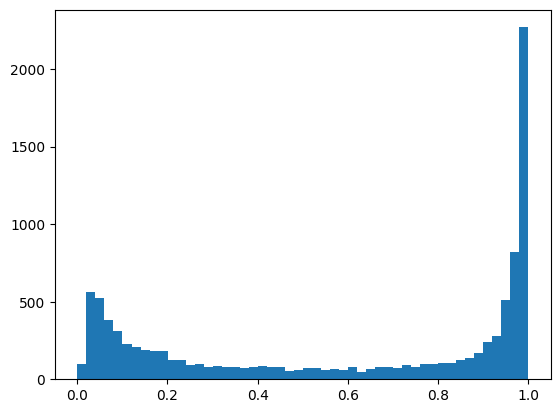

In [5]:
plt.hist(cp.head(10_000).select('clinpred_score').collect(), bins=50)
plt.show()

In [6]:
anno_w_cp = (
    anno
    .join(
        cp.lazy(),
        on=['chrom', 'pos', 'ref', 'alt'],
        how='left'
    )
    .with_columns(
        clinpred_score_is_na = pl.when(pl.col('clinpred_score').is_null()).then(1).otherwise(0),
    )
)

anno_w_cp.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr,cpt1_llr,cpt1_llr_is_na,esm1b_llr_is_na,revel_score_is_na,clinpred_score,clinpred_score_is_na
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f32,f32,f32,i32,i32,i32,f32,i32
"""chr2:124398470:G:T""","""chr2""",124398470,"""G""","""T""","""ENSG00000155052""",1.0,0.0,1.5,0.088186,0.0,"""CNTNAP5|0.00|0.00|0.00|0.00|47…",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-1.57,0.0,0.0,0.0,895934,373184,0.0,0.0,0.027,0.0,…,1,1,0,0,1,1,1,1,1,0,0,0.0,0.0,0.0,0.0,2,2,2,false,false,false,"""ENSG00000155052""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,null,1
"""chr2:71640099:G:A""","""chr2""",71640099,"""G""","""A""","""ENSG00000135636""",1.0,0.0,4.917,0.448087,0.0,"""DYSF|0.00|0.00|0.00|0.00|22|0|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-2.23,0.0,0.0,0.005749,233204,186539,0.0,0.0,0.013,0.0,…,1,1,0,0,1,1,1,1,1,0,0,0.005749,-0.005749,0.0,-0.005168,30,30,30,false,false,false,"""ENSG00000135636""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,null,1
"""chr15:98790075:T:C""","""chr15""",98790075,"""T""","""C""","""ENSG00000140443""",1.0,0.0,15.77,1.793388,0.0,"""IGF1R|0.00|0.00|0.00|0.00|-36|…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-2.88,0.0,0.0,0.012423,315993,141537,0.0,0.0,0.04,0.0,…,1,1,0,0,1,1,1,1,1,0,0,0.012423,-0.012423,0.00348,-0.011761,1,1,1,false,false,false,"""ENSG00000140443""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,null,1
"""chr5:78863633:G:A""","""chr5""",78863633,"""G""","""A""","""ENSG00000113273""",1.0,0.0,2.062,0.172005,0.0,"""ARSB|0.00|0.00|0.00|0.00|-33|1…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-0.28,0.0,0.0,0.005501,208880,122454,0.0,0.0,0.027,0.0,…,1,1,0,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.0,-0.004939,2,2,2,false,false,false,"""ENSG00000113273""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,null,1
"""chr17:73556038:G:C""","""chr17""",73556038,"""G""","""C""","""ENSG00000069188""",1.0,0.0,0.014,-1.156965,0.0,"""SDK2|0.00|0.00|0.00|0.00|24|-1…",0,0,0.0,0.0,0.0,0.0,0.0,0.00057,0.000033,0,0,0,0,0,1,-1.28,0.0,0.0,0.006261,310063,88407,0.0,0.0,0.0,0.0,…,1,1,0,0,1,1,1,1,1,0,0,0.006261,-0.006261,0.0,-0.001363,10,10,10,false,false,false,"""ENSG00000069188""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,null,1


In [7]:
# Check coverage
total = anno_w_cp.select(pl.len()).collect().item()
with_cp = anno_w_cp.filter(pl.col('clinpred_score').is_not_null()).select(pl.len()).collect().item()
print(f"Variants with ClinPred scores: {with_cp} / {total} ({100*with_cp/total:.1f}%)")

anno_w_cp.filter(pl.col('consequence_missense_variant')==1).collect()

Variants with ClinPred scores: 1605743 / 77176753 (2.1%)


id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,motifehipos_is_na,motifescorechng_is_na,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr,cpt1_llr,cpt1_llr_is_na,esm1b_llr_is_na,revel_score_is_na,clinpred_score,clinpred_score_is_na
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f32,f32,f32,i32,i32,i32,f32,i32
"""chr1:203714198:A:G""","""chr1""",203714198,"""A""","""G""","""ENSG00000058668""",0.1,0.0,20.9,2.947236,0.0,"""ATP2B4|0.00|0.00|0.00|0.00|-27…",0,0,0.64,0.0,0.0,0.0,0.0,0.003,0.000428,0,0,0,0,0,1,-6.18,0.0,0.277156,0.083404,117296,87412,0.0,2327.0,0.053,0.0,…,1,1,0,0,0,0,0,1,1,0,0,0.083404,-0.083404,-0.012029,-0.074242,1,1,1,true,true,false,"""ENSG00000058668""","""776/1205""","""H/R""",false,false,false,false,false,0.28,0.0,0.0,1,1,0,0.136704,0
"""chr19:8958169:T:C""","""chr19""",8958169,"""T""","""C""","""ENSG00000181143""",1.0,0.0,6.779,0.63426,0.0,"""MUC16|0.00|0.00|0.00|0.00|44|-…",0,0,0.43,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.39,0.0,0.0,0.007069,132500,23173,0.0,18601.0,0.0,0.0,…,1,1,0,0,0,0,0,1,1,0,0,0.007069,-0.006063,0.007069,-0.000103,1,1,1,true,false,true,"""ENSG00000181143""","""6241/14569""","""N/D""",false,false,false,false,false,0.044,0.0,0.0,1,1,0,0.032728,0
"""chr11:71092531:A:G""","""chr11""",71092531,"""A""","""G""","""ENSG00000162105""",0.0,0.177,23.4,3.739258,0.0,"""SHANK2|0.00|0.06|0.00|0.00|48|…",0,0,0.14,0.0,0.06,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-11.27,0.0,0.902147,0.083404,784725,160046,0.0,803.0,0.093,0.0,…,1,1,0,0,0,0,0,1,1,0,0,0.083404,-0.083404,0.0,-0.00654,1,1,1,true,true,false,"""ENSG00000162105""","""268/1849""","""L/P""",false,false,false,true,false,0.921,0.0,0.0,1,1,0,0.996993,0
"""chr11:71092531:A:G""","""chr11""",71092531,"""A""","""G""","""ENSG00000162105""",0.0,0.177,23.4,3.739258,0.0,"""SHANK2|0.00|0.06|0.00|0.00|48|…",0,0,0.14,0.0,0.06,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-11.27,0.0,0.902147,0.083404,784725,160046,0.0,803.0,0.093,0.0,…,1,1,0,0,0,0,0,1,1,0,0,0.083404,-0.083404,0.0,-0.00654,1,1,1,true,true,false,"""ENSG00000162105""","""268/1849""","""L/P""",false,false,false,true,false,0.921,0.0,0.0,1,1,0,0.996993,0
"""chr9:137013967:G:A""","""chr9""",137013967,"""G""","""A""","""ENSG00000107331""",0.0,0.824,27.200001,4.882186,0.0,"""ABCA2|0.00|0.00|0.00|0.09|-6|3…",0,0,0.59,0.0,0.09,0.0,0.0,0.003,0.000341,0,0,0,0,0,1,-6.83,0.0,0.663058,0.060269,21683,14948,0.0,4312.0,0.147,0.0,…,1,1,0,0,0,0,0,1,1,0,0,0.060269,-0.060269,0.0,-0.054068,2,2,2,true,true,false,"""ENSG00000107331""","""1438/2436""","""R/C""",false,false,false,false,false,0.677,0.0,0.0,1,1,0,0.489466,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr2:178782820:T:C""","""chr2""",178782820,"""T""","""C""","""ENSG00000155657""",1.0,0.0,23.9,3.938593,0.5955,"""TTN|0.00|0.00|0.00|0.00|38|11|…",0,0,0.03,0.

In [8]:
anno_w_cp = (
    anno_w_cp
    .with_columns(
        clinpred_score = pl.col('clinpred_score').fill_null(0.0).cast(pl.Float32),
    )
    .collect()
)

In [9]:
anno_w_cp.write_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all_with_clinpred.parquet")

---
# Add BayesDel

https://fenglab.chpc.utah.edu/BayesDel/BayesDel.html

In [3]:
bd = (
    pl.scan_csv(
        "/s/project/deeprvat/ukb_gym/annotation_files/bayesdel/BayesDel_170824_noAF.GRCh38.gz", 
        separator='\t',
        schema_overrides={
            '#Chr': pl.Utf8,
        },
        ignore_errors=True
    )
    .with_columns(
        chrom = 'chr' + pl.col('#Chr').cast(pl.Utf8),
    )
    .rename({
        'Start': 'pos',
        'BayesDel_nsfp33a_noAF': 'bayes_del'
    })
    .drop('#Chr')
)

bd.head().collect()

pos,ref,alt,bayes_del,chrom
i64,str,str,f64,str
69091,"""A""","""C""",-0.756339,"""chr1"""
69091,"""A""","""G""",-0.835748,"""chr1"""
69091,"""A""","""T""",-0.756353,"""chr1"""
69092,"""T""","""A""",-0.63302,"""chr1"""
69092,"""T""","""C""",-0.769191,"""chr1"""


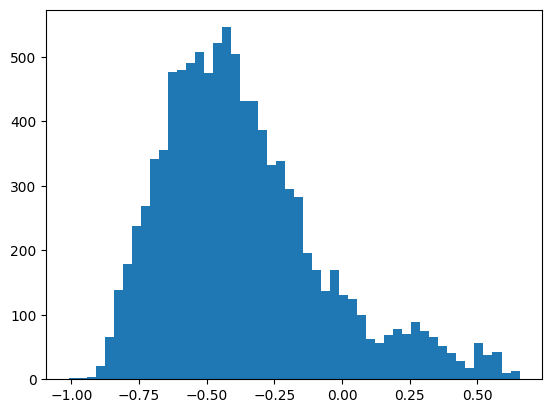

In [5]:
plt.hist(bd.head(10_000).select('bayes_del').collect(), bins=50)
plt.show()

In [6]:
anno_w_cp = pl.scan_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all_with_clinpred.parquet")

anno_w_bd = (
    anno_w_cp
    .join(
        bd.lazy(),
        on=['chrom', 'pos', 'ref', 'alt'],
        how='left'
    )
    .with_columns(
        bayes_del_is_na = pl.when(pl.col('bayes_del').is_null()).then(1).otherwise(0),
    )
)

anno_w_bd.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr,cpt1_llr,cpt1_llr_is_na,esm1b_llr_is_na,revel_score_is_na,clinpred_score,clinpred_score_is_na,bayes_del,bayes_del_is_na
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f32,f32,f32,i32,i32,i32,f32,i32,f64,i32
"""chr2:124398470:G:T""","""chr2""",124398470,"""G""","""T""","""ENSG00000155052""",1.0,0.0,1.5,0.088186,0.0,"""CNTNAP5|0.00|0.00|0.00|0.00|47…",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-1.57,0.0,0.0,0.0,895934,373184,0.0,0.0,0.027,0.0,…,0,0,1,1,1,1,1,0,0,0.0,0.0,0.0,0.0,2,2,2,false,false,false,"""ENSG00000155052""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,null,1
"""chr2:71640099:G:A""","""chr2""",71640099,"""G""","""A""","""ENSG00000135636""",1.0,0.0,4.917,0.448087,0.0,"""DYSF|0.00|0.00|0.00|0.00|22|0|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-2.23,0.0,0.0,0.005749,233204,186539,0.0,0.0,0.013,0.0,…,0,0,1,1,1,1,1,0,0,0.005749,-0.005749,0.0,-0.005168,30,30,30,false,false,false,"""ENSG00000135636""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,null,1
"""chr15:98790075:T:C""","""chr15""",98790075,"""T""","""C""","""ENSG00000140443""",1.0,0.0,15.77,1.793388,0.0,"""IGF1R|0.00|0.00|0.00|0.00|-36|…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-2.88,0.0,0.0,0.012423,315993,141537,0.0,0.0,0.04,0.0,…,0,0,1,1,1,1,1,0,0,0.012423,-0.012423,0.00348,-0.011761,1,1,1,false,false,false,"""ENSG00000140443""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,null,1
"""chr5:78863633:G:A""","""chr5""",78863633,"""G""","""A""","""ENSG00000113273""",1.0,0.0,2.062,0.172005,0.0,"""ARSB|0.00|0.00|0.00|0.00|-33|1…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-0.28,0.0,0.0,0.005501,208880,122454,0.0,0.0,0.027,0.0,…,0,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.0,-0.004939,2,2,2,false,false,false,"""ENSG00000113273""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,null,1
"""chr17:73556038:G:C""","""chr17""",73556038,"""G""","""C""","""ENSG00000069188""",1.0,0.0,0.014,-1.156965,0.0,"""SDK2|0.00|0.00|0.00|0.00|24|-1…",0,0,0.0,0.0,0.0,0.0,0.0,0.00057,0.000033,0,0,0,0,0,1,-1.28,0.0,0.0,0.006261,310063,88407,0.0,0.0,0.0,0.0,…,0,0,1,1,1,1,1,0,0,0.006261,-0.006261,0.0,-0.001363,10,10,10,false,false,false,"""ENSG00000069188""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,null,1


In [7]:
# Check coverage
total = anno_w_bd.select(pl.len()).collect().item()
with_bd = anno_w_bd.filter(pl.col('bayes_del').is_not_null()).select(pl.len()).collect().item()
print(f"Variants with BayesDel scores: {with_bd} / {total} ({100*with_bd/total:.1f}%)")

anno_w_bd.filter(pl.col('consequence_missense_variant')==1).collect()

Variants with BayesDel scores: 1717252 / 77176755 (2.2%)


id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,priphcons_is_na,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr,cpt1_llr,cpt1_llr_is_na,esm1b_llr_is_na,revel_score_is_na,clinpred_score,clinpred_score_is_na,bayes_del,bayes_del_is_na
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f32,f32,f32,i32,i32,i32,f32,i32,f64,i32
"""chr1:203714198:A:G""","""chr1""",203714198,"""A""","""G""","""ENSG00000058668""",0.1,0.0,20.9,2.947236,0.0,"""ATP2B4|0.00|0.00|0.00|0.00|-27…",0,0,0.64,0.0,0.0,0.0,0.0,0.003,0.000428,0,0,0,0,0,1,-6.18,0.0,0.277156,0.083404,117296,87412,0.0,2327.0,0.053,0.0,…,0,0,0,0,0,1,1,0,0,0.083404,-0.083404,-0.012029,-0.074242,1,1,1,true,true,false,"""ENSG00000058668""","""776/1205""","""H/R""",false,false,false,false,false,0.28,0.0,0.0,1,1,0,0.136704,0,-0.247352,0
"""chr19:8958169:T:C""","""chr19""",8958169,"""T""","""C""","""ENSG00000181143""",1.0,0.0,6.779,0.63426,0.0,"""MUC16|0.00|0.00|0.00|0.00|44|-…",0,0,0.43,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.39,0.0,0.0,0.007069,132500,23173,0.0,18601.0,0.0,0.0,…,0,0,0,0,0,1,1,0,0,0.007069,-0.006063,0.007069,-0.000103,1,1,1,true,false,true,"""ENSG00000181143""","""6241/14569""","""N/D""",false,false,false,false,false,0.044,0.0,0.0,1,1,0,0.032728,0,-0.794568,0
"""chr11:71092531:A:G""","""chr11""",71092531,"""A""","""G""","""ENSG00000162105""",0.0,0.177,23.4,3.739258,0.0,"""SHANK2|0.00|0.06|0.00|0.00|48|…",0,0,0.14,0.0,0.06,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-11.27,0.0,0.902147,0.083404,784725,160046,0.0,803.0,0.093,0.0,…,0,0,0,0,0,1,1,0,0,0.083404,-0.083404,0.0,-0.00654,1,1,1,true,true,false,"""ENSG00000162105""","""268/1849""","""L/P""",false,false,false,true,false,0.921,0.0,0.0,1,1,0,0.996993,0,0.308212,0
"""chr11:71092531:A:G""","""chr11""",71092531,"""A""","""G""","""ENSG00000162105""",0.0,0.177,23.4,3.739258,0.0,"""SHANK2|0.00|0.06|0.00|0.00|48|…",0,0,0.14,0.0,0.06,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-11.27,0.0,0.902147,0.083404,784725,160046,0.0,803.0,0.093,0.0,…,0,0,0,0,0,1,1,0,0,0.083404,-0.083404,0.0,-0.00654,1,1,1,true,true,false,"""ENSG00000162105""","""268/1849""","""L/P""",false,false,false,true,false,0.921,0.0,0.0,1,1,0,0.996993,0,0.308212,0
"""chr9:137013967:G:A""","""chr9""",137013967,"""G""","""A""","""ENSG00000107331""",0.0,0.824,27.200001,4.882186,0.0,"""ABCA2|0.00|0.00|0.00|0.09|-6|3…",0,0,0.59,0.0,0.09,0.0,0.0,0.003,0.000341,0,0,0,0,0,1,-6.83,0.0,0.663058,0.060269,21683,14948,0.0,4312.0,0.147,0.0,…,0,0,0,0,0,1,1,0,0,0.060269,-0.060269,0.0,-0.054068,2,2,2,true,true,false,"""ENSG00000107331""","""1438/2436""","""R/C""",false,false,false,false,false,0.677,0.0,0.0,1,1,0,0.489466,0,0.129093,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr2:178782820:T:C""","""chr2""",178782820,"""T""","""C""","""ENSG00000155657""",1.0,0.0,23.9,3.938593,0.5955,"""TTN|0.00|0.00|0.00|

In [8]:
bd_median = bd.select('bayes_del').collect().median().item()
bd_median

-0.249576

In [9]:
anno_w_bd = (
    anno_w_bd
    .with_columns(
        bayes_del = pl.col('bayes_del').fill_null(bd_median).cast(pl.Float32),
    )
    .collect()
)

In [10]:
anno_w_bd.write_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all_with_clinpred_bayesdel.parquet")

---
# Add popEVE

https://pop.evemodel.org/documentation

`wget https://data.evemodel.org/popeve/v1.1/downloads/grch38_popEVE_ukbb_20250715.vcf.gz`

In [4]:
pe = (
    pl.read_csv(
        '/s/project/deeprvat/ukb_gym/annotation_files/popeve/grch38_popEVE_ukbb_20250715.vcf.gz', 
        separator='\t',
        ignore_errors=True,
    )
    .rename({
        '#CHROM': 'chrom',
        'POS': 'pos',
        'REF': 'ref',
        'ALT': 'alt',
    })
    .select(['chrom', 'pos', 'ref', 'alt', 'INFO'])
    .with_columns(
        # Extract everything after 'protein=' until the next ';' or end of string
        protein = pl.col('INFO').str.extract(r"protein=([^;]+)"),
        
        # Extract everything after 'gene=' until the next ';' or end of string
        gene_name = pl.col('INFO').str.extract(r"gene=([^;]+)"),
        mutant = pl.col('INFO').str.extract(r"mutant=([^;]+)"),
        
        popeve_score = pl.col('INFO').str.extract(r"popEVE=([^;]+)").cast(pl.Float32),
        eve_score = pl.col('INFO').str.extract(r"EVE=([^;]+)").cast(pl.Float32),
        pop_adj_eve = pl.col('INFO').str.extract(r"pop-adjusted_EVE=([^;]+)").cast(pl.Float32),
        pop_adj_esm1v = pl.col('INFO').str.extract(r"pop-adjusted_ESM1v=([^;]+)").cast(pl.Float32),
    )
    .with_columns(
        ref_aa=pl.col('mutant').str.slice(0, 1),
        alt_aa=pl.col('mutant').str.slice(-1, 1),
        prot_pos=pl.col('mutant').str.slice(1, pl.col('mutant').str.len_chars() - 2),
    )
    .with_columns(
        amino_acids=pl.col('ref_aa') + '/' + pl.col('alt_aa'),
    )
    .select(['gene_name', 'amino_acids', 'prot_pos', 'popeve_score', 'eve_score', 'pop_adj_eve', 'pop_adj_esm1v'])
)

pe

gene_name,amino_acids,prot_pos,popeve_score,eve_score,pop_adj_eve,pop_adj_esm1v
str,str,str,f32,f32,f32,f32
"""PANK4""","""E/D""","""773""",-5.66,-5.66,-4.027,-7.293
"""PANK4""","""E/D""","""773""",-5.66,-5.66,-4.027,-7.293
"""PANK4""","""E/A""","""773""",-5.606,-5.606,-4.079,-7.133
"""PANK4""","""E/V""","""773""",-5.703,-5.703,-4.07,-7.336
"""PANK4""","""E/G""","""773""",-5.612,-5.612,-4.029,-7.196
…,…,…,…,…,…,…
"""SPRY3""","""V/L""","""288""",-2.929,-2.929,-2.901,-2.957
"""SPRY3""","""V/I""","""288""",-2.962,-2.962,-2.909,-3.015
"""SPRY3""","""V/A""","""288""",-2.918,-2.918,-2.878,-2.959


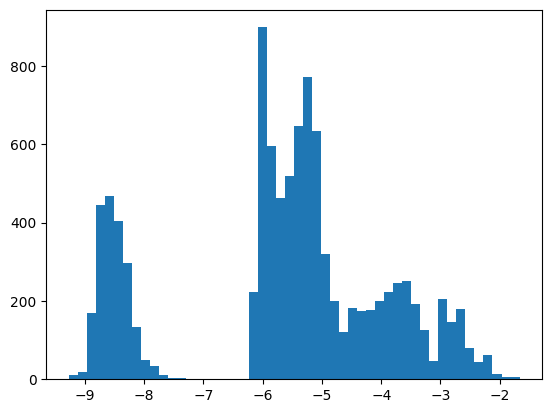

In [5]:
plt.hist(pe['popeve_score'].head(10_000), bins=50)
plt.show()

In [6]:
ginfo = (
    pl.read_parquet('/s/project/deeprvat/ukb_gym/genes_info_biomart.parquet')
    .filter(pl.col('gene_type') == 'protein_coding')
    .select(['gene_stable_id', 'gene_name'])
    .rename({'gene_stable_id': 'region'})
    .unique()
)
ginfo

region,gene_name
str,str
"""ENSG00000171121""","""KCNMB3"""
"""ENSG00000174740""","""PABPC5"""
"""ENSG00000100345""","""MYH9"""
"""ENSG00000065054""","""NHERF2"""
"""ENSG00000108424""","""KPNB1"""
…,…
"""ENSG00000103056""","""SMPD3"""
"""ENSG00000166391""","""MOGAT2"""
"""ENSG00000141568""","""FOXK2"""


In [7]:
len(set(pe.select(['gene_name']).unique()['gene_name']) - set(ginfo.select(['gene_name']).unique()['gene_name']))

118

In [8]:
anno_w_bd = (
    pl.scan_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all_with_clinpred_bayesdel.parquet")
    .join(
        ginfo.lazy(),
        on='region',
        how='inner'
    )
)
anno_w_bd.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,priphylop_is_na,relcdspos_is_na,relprotpos_is_na,relcdnapos_is_na,toverlapmotifs_is_na,targetscan_is_na,verphcons_is_na,verphylop_is_na,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr,cpt1_llr,cpt1_llr_is_na,esm1b_llr_is_na,revel_score_is_na,clinpred_score,clinpred_score_is_na,bayes_del,bayes_del_is_na,gene_name
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f32,f32,f32,i32,i32,i32,f32,i32,f32,i32,str
"""chr2:124398470:G:T""","""chr2""",124398470,"""G""","""T""","""ENSG00000155052""",1.0,0.0,1.5,0.088186,0.0,"""CNTNAP5|0.00|0.00|0.00|0.00|47…",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-1.57,0.0,0.0,0.0,895934,373184,0.0,0.0,0.027,0.0,…,0,1,1,1,1,1,0,0,0.0,0.0,0.0,0.0,2,2,2,false,false,false,"""ENSG00000155052""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""CNTNAP5"""
"""chr2:71640099:G:A""","""chr2""",71640099,"""G""","""A""","""ENSG00000135636""",1.0,0.0,4.917,0.448087,0.0,"""DYSF|0.00|0.00|0.00|0.00|22|0|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-2.23,0.0,0.0,0.005749,233204,186539,0.0,0.0,0.013,0.0,…,0,1,1,1,1,1,0,0,0.005749,-0.005749,0.0,-0.005168,30,30,30,false,false,false,"""ENSG00000135636""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""DYSF"""
"""chr15:98790075:T:C""","""chr15""",98790075,"""T""","""C""","""ENSG00000140443""",1.0,0.0,15.77,1.793388,0.0,"""IGF1R|0.00|0.00|0.00|0.00|-36|…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-2.88,0.0,0.0,0.012423,315993,141537,0.0,0.0,0.04,0.0,…,0,1,1,1,1,1,0,0,0.012423,-0.012423,0.00348,-0.011761,1,1,1,false,false,false,"""ENSG00000140443""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""IGF1R"""
"""chr5:78863633:G:A""","""chr5""",78863633,"""G""","""A""","""ENSG00000113273""",1.0,0.0,2.062,0.172005,0.0,"""ARSB|0.00|0.00|0.00|0.00|-33|1…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-0.28,0.0,0.0,0.005501,208880,122454,0.0,0.0,0.027,0.0,…,0,1,1,1,1,1,0,0,0.005501,-0.005501,0.0,-0.004939,2,2,2,false,false,false,"""ENSG00000113273""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""ARSB"""
"""chr17:73556038:G:C""","""chr17""",73556038,"""G""","""C""","""ENSG00000069188""",1.0,0.0,0.014,-1.156965,0.0,"""SDK2|0.00|0.00|0.00|0.00|24|-1…",0,0,0.0,0.0,0.0,0.0,0.0,0.00057,0.000033,0,0,0,0,0,1,-1.28,0.0,0.0,0.006261,310063,88407,0.0,0.0,0.0,0.0,…,0,1,1,1,1,1,0,0,0.006261,-0.006261,0.0,-0.001363,10,10,10,false,false,false,"""ENSG00000069188""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""SDK2"""


In [9]:
anno_with_popeve = (
    anno_w_bd
    .with_columns(
        prot_pos=pl.col('protein_position').str.split('/').list.get(0)
    )
    .join(
        pe.lazy(),
        on=['gene_name', 'amino_acids', 'prot_pos'],
        how='left'
    )
    .with_columns(
        popeve_score_is_na = pl.when(pl.col('popeve_score').is_null()).then(0).otherwise(1),
        eve_score_is_na = pl.when(pl.col('eve_score').is_null()).then(0).otherwise(1),
        pop_adj_eve_is_na = pl.when(pl.col('pop_adj_eve').is_null()).then(0).otherwise(1),
        pop_adj_esm1v_is_na = pl.when(pl.col('pop_adj_esm1v').is_null()).then(0).otherwise(1),
    )
    .drop('prot_pos')
    .collect()
)

anno_with_popeve

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,spliceai_pred,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,…,abexp_abs_max_right,abexp_min,abexp_max,abexp_mean,sc_ukb,ac_ukb,mac_ukb,vep_cds_relaxed,mane_cds,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr,cpt1_llr,cpt1_llr_is_na,esm1b_llr_is_na,revel_score_is_na,clinpred_score,clinpred_score_is_na,bayes_del,bayes_del_is_na,gene_name,popeve_score,eve_score,pop_adj_eve,pop_adj_esm1v,popeve_score_is_na,eve_score_is_na,pop_adj_eve_is_na,pop_adj_esm1v_is_na
str,str,i64,str,str,str,f32,f32,f32,f32,f32,str,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,…,f32,f32,f32,f32,u64,i64,i64,bool,bool,bool,str,str,str,bool,bool,bool,bool,bool,f32,f32,f32,i32,i32,i32,f32,i32,f32,i32,str,f32,f32,f32,f32,i32,i32,i32,i32
"""chr2:124398470:G:T""","""chr2""",124398470,"""G""","""T""","""ENSG00000155052""",1.0,0.0,1.5,0.088186,0.0,"""CNTNAP5|0.00|0.00|0.00|0.00|47…",0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-1.57,0.0,0.0,0.0,895934,373184,0.0,0.0,0.027,0.0,…,0.0,0.0,0.0,0.0,2,2,2,false,false,false,"""ENSG00000155052""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""CNTNAP5""",null,null,null,null,0,0,0,0
"""chr2:71640099:G:A""","""chr2""",71640099,"""G""","""A""","""ENSG00000135636""",1.0,0.0,4.917,0.448087,0.0,"""DYSF|0.00|0.00|0.00|0.00|22|0|…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-2.23,0.0,0.0,0.005749,233204,186539,0.0,0.0,0.013,0.0,…,0.005749,-0.005749,0.0,-0.005168,30,30,30,false,false,false,"""ENSG00000135636""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""DYSF""",null,null,null,null,0,0,0,0
"""chr15:98790075:T:C""","""chr15""",98790075,"""T""","""C""","""ENSG00000140443""",1.0,0.0,15.77,1.793388,0.0,"""IGF1R|0.00|0.00|0.00|0.00|-36|…",0,0,0.0,0.0,0.0,0.01,0.0,0.001,0.000034,0,0,0,0,0,1,-2.88,0.0,0.0,0.012423,315993,141537,0.0,0.0,0.04,0.0,…,0.012423,-0.012423,0.00348,-0.011761,1,1,1,false,false,false,"""ENSG00000140443""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""IGF1R""",null,null,null,null,0,0,0,0
"""chr5:78863633:G:A""","""chr5""",78863633,"""G""","""A""","""ENSG00000113273""",1.0,0.0,2.062,0.172005,0.0,"""ARSB|0.00|0.00|0.00|0.00|-33|1…",0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-0.28,0.0,0.0,0.005501,208880,122454,0.0,0.0,0.027,0.0,…,0.005501,-0.005501,0.0,-0.004939,2,2,2,false,false,false,"""ENSG00000113273""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""ARSB""",null,null,null,null,0,0,0,0
"""chr17:73556038:G:C""","""chr17""",73556038,"""G""","""C""","""ENSG00000069188""",1.0,0.0,0.014,-1.156965,0.0,"""SDK2|0.00|0.00|0.00|0.00|24|-1…",0,0,0.0,0.0,0.0,0.0,0.0,0.00057,0.000033,0,0,0,0,0,1,-1.28,0.0,0.0,0.006261,310063,88407,0.0,0.0,0.0,0.0,…,0.006261,-0.006261,0.0,-0.001363,10,10,10,false,false,false,"""ENSG00000069188""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""SDK2""",null,null,null,null,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr15:67187601:C:G""","""chr15""",67187601,"""C""","""G""","""ENSG00000166949""",1.0,0.0,2.137,0.181512,0.0,"""SMAD3|0.00|0.00|0.00|0.00|9|3|…",0,0,0.0,0.0,0.0,0.0,0.0,0.003,0.000321,0,0,0,0,0,

In [10]:
# Check coverage
total = anno_with_popeve.select(pl.len()).item()
with_pe = anno_with_popeve.filter(pl.col('popeve_score').is_not_null()).select(pl.len()).item()
print(f"Variants with popEVE scores: {with_pe} / {total} ({100*with_pe/total:.1f}%)")

Variants with popEVE scores: 1074048 / 77332281 (1.4%)


In [11]:
popeve_score_median = pe.select('popeve_score').median().item()
eve_score_median = pe.select('eve_score').median().item()
pop_adj_eve_median = pe.select('pop_adj_eve').median().item()
pop_adj_esm1v_median = pe.select('pop_adj_esm1v').median().item()

print(f"popEVE score median: {popeve_score_median}")
print(f"EVE score median: {eve_score_median}")
print(f"pop-adjusted EVE score median: {pop_adj_eve_median}")
print(f"pop-adjusted ESM1v score median: {pop_adj_esm1v_median}")

popEVE score median: -3.3580000400543213
EVE score median: -3.3580000400543213
pop-adjusted EVE score median: -3.4130001068115234
pop-adjusted ESM1v score median: -3.2790000438690186


In [12]:
(
    anno_with_popeve
    .with_columns(
        popeve_score = pl.col('popeve_score').fill_null(popeve_score_median).cast(pl.Float32),
        eve_score = pl.col('eve_score').fill_null(eve_score_median).cast(pl.Float32),
        pop_adj_eve = pl.col('pop_adj_eve').fill_null(pop_adj_eve_median).cast(pl.Float32),
        pop_adj_esm1v = pl.col('pop_adj_esm1v').fill_null(pop_adj_esm1v_median).cast(pl.Float32),
    )
    .write_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all_with_clinpred_bayesdel_popeve.parquet")
)

---
# Add ClinVar

In [4]:
LOCAL_ANNO_DIR = "/s/project/deeprvat/ukb_gym/annotation_files"

# Download ClinVar VCF (GRCh38) and its index
!mkdir -p {LOCAL_ANNO_DIR}/clinvar
!wget -nc https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz -O {LOCAL_ANNO_DIR}/clinvar/clinvar.vcf.gz
!wget -nc https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz.tbi -O {LOCAL_ANNO_DIR}/clinvar/clinvar.vcf.gz.tbi

--2026-03-03 10:06:22--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 2607:f220:41e:250::10, 2607:f220:41e:250::7, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|2607:f220:41e:250::10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 190245250 (181M) [application/x-gzip]
Saving to: ‘/s/project/deeprvat/ukb_gym/annotation_files/clinvar/clinvar.vcf.gz’

/s/project/deeprvat 100%[===================>] 181.43M  17.8MB/s    in 12s     

2026-03-03 10:06:34 (15.7 MB/s) - ‘/s/project/deeprvat/ukb_gym/annotation_files/clinvar/clinvar.vcf.gz’ saved [190245250/190245250]

--2026-03-03 10:06:34--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz.tbi
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 2607:f220:41e:250::10, 2607:f220:41e:250::7, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|2607:f22

In [11]:
clinvar = (
    pl.read_csv(f"{LOCAL_ANNO_DIR}/clinvar/clinvar.vcf.gz", comment_prefix="##", separator="\t", ignore_errors=True)
    .with_columns(
        chrom = 'chr' + pl.col("#CHROM").fill_null("NA").cast(str),
    
        # Look for "CLNSIG=", capture everything until the next semicolon
        clinical_significance = pl.col("INFO").str.extract(r"CLNSIG=([^;]+)", 1),
    )
    .drop(['#CHROM', 'ID', 'QUAL', 'FILTER'])
    .rename({
        "POS": "pos",
        "REF": "ref",
        "ALT": "alt",
        "INFO": "info",
    })
    .with_columns(
        id = pl.col("chrom") + ":" + pl.col("pos").cast(str) + ":" + pl.col("ref") + ":" + pl.col("alt"),

        # Look for "MC=", skip characters until pipe "|", capture text until next comma or semicolon
        variant_region = pl.col("info").str.extract(r"MC=[^|]+\|([^;,]+)", 1),
    )
    .select(['id', 'clinical_significance'])
    .unique()
)

clinvar

id,clinical_significance
str,str
"""chr2:39755934:C:A""","""Uncertain_significance"""
"""chr4:95206678:C:T""","""Uncertain_significance"""
"""chr10:73817113:T:C""","""Uncertain_significance"""
"""chr7:128972452:G:C""","""Uncertain_significance"""
"""chr1:100007151:G:T""","""Uncertain_significance"""
…,…
"""chr2:177420341:T:C""","""Likely_benign"""
"""chr6:131890489:C:T""","""Uncertain_significance"""
"""chr17:17216473:T:C""","""Uncertain_significance"""


In [20]:
clinvar['clinical_significance'].value_counts(sort=True).head(10)

clinical_significance,count
str,u64
"""Uncertain_significance""",2291109
"""Likely_benign""",1074756
null,243736
"""Benign""",208931
"""Pathogenic""",184325
"""Conflicting_classifications_of…",162219
"""Likely_pathogenic""",110199
"""Benign/Likely_benign""",63591
"""Pathogenic/Likely_pathogenic""",36446


In [14]:
# anno_with_popeve = pl.scan_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all_with_clinpred_bayesdel_popeve.parquet")
anno_with_popeve = pl.scan_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all.parquet").drop('spliceai_pred')
anno_with_popeve.head().collect()

id,chrom,pos,ref,alt,region,sift,polyphen,cadd_phred,cadd_raw,am_pathogenicity,loftee_hc,loftee_lc,relative_cds_position,next_in_frame_relative,spliceai_delta_score,pangolin_score,delta_score,absplice_dna_max,absplice2_max,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_ustop_gained,five_prime_utr_variant_consequence_ustop_lost,variant_length,gpn_score,promoterai,score_pai3d,abexp_abs_max,gene_length,dist_to_tss,aparent2,cdspos,cpg,dst2splice,esmscoreframeshift,…,non_mane_cds,region_right,protein_position,amino_acids,mobi_full_disorder_priority,mobi_curated_disorder_priority,mobi_full_lip_priority,ted_domain,low_complexity_domain,revel_score,esm1b_llr,cpt1_llr,cpt1_llr_is_na,esm1b_llr_is_na,revel_score_is_na,clinpred_score,clinpred_score_is_na,bayes_del,bayes_del_is_na,gene_name,popeve_score,eve_score,pop_adj_eve,pop_adj_esm1v,popeve_score_is_na,eve_score_is_na,pop_adj_eve_is_na,pop_adj_esm1v_is_na,not_annotated_in_encode,encode_dels,encode_ca-ctcf,encode_ca,encode_ca-h3k4me3,encode_tf,encode_ca-tf,encode_pels,encode_pls
str,str,i64,str,str,str,f32,f32,f32,f32,f32,i8,i8,f32,f32,f32,f32,f32,f32,f32,u8,u8,u8,u8,u8,u32,f32,f32,f32,f32,i64,i64,f32,f32,f32,f32,f32,…,bool,str,str,str,bool,bool,bool,bool,bool,f32,f32,f32,i32,i32,i32,f32,i32,f32,i32,str,f32,f32,f32,f32,i32,i32,i32,i32,bool,bool,bool,bool,bool,bool,bool,bool,bool
"""chr18:801825:T:C""","""chr18""",801825,"""T""","""C""","""ENSG00000176105""",1.0,0.0,2.912,0.265924,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.00057,0.000033,0,0,0,0,0,1,-1.23,0.0,0.0,0.006286,90960,10721,0.0,0.0,0.013,0.0,0.0,…,false,"""ENSG00000176105""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""YES1""",-3.358,-3.358,-3.413,-3.279,0,0,0,0,true,false,false,false,false,false,false,false,false
"""chr11:73713524:C:T""","""chr11""",73713524,"""C""","""T""","""ENSG00000175582""",1.0,0.0,4.127,0.376508,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,1.16,0.0,0.0,0.006189,85501,47613,0.0,0.0,0.067,0.0,0.0,…,false,"""ENSG00000175582""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""RAB6A""",-3.358,-3.358,-3.413,-3.279,0,0,0,0,false,false,true,false,false,false,false,false,false
"""chr3:186639770:G:C""","""chr3""",186639770,"""G""","""C""","""ENSG00000090512""",1.0,0.0,2.513,0.225062,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.001,0.000033,0,0,0,0,0,1,-1.49,0.0,0.0,0.006871,17174,3802,0.0,0.0,0.0,0.0,0.0,…,false,"""ENSG00000090512""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""FETUB""",-3.358,-3.358,-3.413,-3.279,0,0,0,0,true,false,false,false,false,false,false,false,false
"""chr2:115830766:G:A""","""chr2""",115830766,"""G""","""A""","""ENSG00000175497""",1.0,0.0,1.062,-0.00231,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,-1.04,0.0,0.0,0.005501,1403483,1388468,0.0,0.0,0.0,0.0,0.0,…,false,"""ENSG00000175497""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""DPP10""",-3.358,-3.358,-3.413,-3.279,0,0,0,0,true,false,false,false,false,false,false,false,false
"""chr20:47356435:G:A""","""chr20""",47356435,"""G""","""A""","""ENSG00000101040""",1.0,0.0,16.07,1.855359,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.003,0.000244,0,0,0,0,0,1,-3.49,0.1237,0.0,0.069273,147677,454,0.0,0.0,0.0,0.0,0.0,…,false,"""ENSG00000101040""",null,null,false,false,false,false,false,0.0,0.0,0.0,1,1,1,0.0,1,-0.249576,1,"""ZMYND8""",-3.358,-3.358,-3.413,-3.279,0,0,0,0,true,false,false,false,false,false,false,false,false


In [15]:
(
    anno_with_popeve
    .join(
        clinvar.lazy(),
        on='id',
        how='left'
    )
    .sink_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all_with_clinvar.parquet", engine='streaming')
)

---
# Save and upload

In [ ]:
anno_with_all = pl.scan_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all_with_clinvar.parquet")

encode_cols = [c for c in anno_with_all.collect_schema().names() if 'encode']
# Check is encode columns are present in the new dataframe
if len(encode_cols) == 0:
    print("Adding ENCODE annotations...")
    RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
    ANNO_FILE = "annotations_with_all_old.parquet"
    !dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_DATA_DIR}/{ANNO_FILE}

    anno_enc = (
        pl.scan_parquet(f"{LOCAL_DATA_DIR}/{ANNO_FILE}")
        .select(['id', 'region', 'not_annotated_in_encode', 'encode_dels', 'encode_ca-ctcf', 'encode_ca', 'encode_ca-h3k4me3', 'encode_tf', 'encode_ca-tf', 'encode_pels', 'encode_pls'])
        .collect()
    )

    anno_with_all = (
        anno_with_all
        .join(
            anno_enc.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

print("Dropping duplicates and writing final dataframe...")
(
    anno_with_all
    .unique()
    .sink_parquet(f"{LOCAL_DATA_DIR}/annotations_with_all.parquet")
)

In [17]:
!dx upload {LOCAL_DATA_DIR}/annotations_with_all.parquet --path {RAP_DATA_DIR}/

[===========================================================>] Uploaded 6,594,253,417 of 6,594,253,417 bytes (100%) /s/project/deeprvat_wgs/input_data/annotations/qced_maf1e-3_loftee_olink_genes_EURunrelated//annotations_with_all.parquet>                                                        ] Uploaded 419,430,400 of 6,594,253,417 bytes (6%) /s/project/deeprvat_wgs/input_data/annotations/qced_maf1e-3_loftee_olink_genes_EURunrelated//annotations_with_all.parquet[===>                                                        ] Uploaded 436,207,616 of 6,594,253,417 bytes (7%) /s/project/deeprvat_wgs/input_data/annotations/qced_maf1e-3_loftee_olink_genes_EURunrelated//annotations_with_all.parquet
ID                                file-J6YBQQQJg0yF8ZG2q2yPy6QK
Class                             file
Project                           project-Gyp4fvjJg0yFZ374KvP9bGFJ
Folder                            /processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_l
                             